# **Course 3 - Supervised Machine Learning Classification**

**HR attrition project**

Employee turnover is costly because hiring and training replacements takes time and money. Salifort Motors wants to understand which employees are likely to leave and what workplace factors may increase that risk.

## **Dataset Description**

This project uses the public Kaggle HR Analytics dataset: [HR Analytics and Job Prediction](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv). The dataset contains employee information that can be used to study and predict employee turnover. 

The original dataset has 14,999 employee records and 10 columns. After removing duplicate rows, the modeling dataset has 11,991 records. The target variable is `left`, where `1` means the employee left the company and `0` means the employee stayed.

The main predictor variables are:

| Variable | Description |
| --- | --- |
| `satisfaction_level` | Employee satisfaction score from 0 to 1 |
| `last_evaluation` | Most recent performance evaluation score from 0 to 1 |
| `number_project` | Number of projects assigned to the employee |
| `average_monthly_hours` | Average monthly hours worked |
| `tenure` | Number of years at the company |
| `work_accident` | Whether the employee had a workplace accident |
| `promotion_last_5years` | Whether the employee was promoted in the last five years |
| `department` | Employee department |
| `salary` | Salary level: low, medium, or high |

This dataset is useful for classification because it includes workload, satisfaction, evaluation, salary, and department information that may help predict whether an employee leaves.


## **Main Objectives**

The objective of this project is to build a supervised classification model that predicts the `left` target variable. The project also compares several classification methods and explains the final model in clear business terms.

The main goals are to:

- Explore and clean the HR dataset.
- Check class balance and prepare the data for modeling.
- Build and compare multiple classification models.
- Select the best model based on performance, interpretability, and business usefulness.
- Identify the factors most related to employee turnover.
- Provide practical recommendations to help HR reduce attrition.

The model should support better retention decisions. It should not be used to punish or unfairly label employees.


## **Exploratory Data Analysis**
### **Step 1. Setup**

#### **Import packages**

In [690]:
# Import packages
# ===== Core packages =====
import numpy as np
import pandas as pd

# ===== Visualization =====
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ===== Modeling: scikit-learn classifiers =====
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# ===== Modeling: XGBoost =====
from xgboost import XGBClassifier, XGBRegressor, plot_importance

# ===== Preprocessing =====
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    label_binarize,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ===== Model selection =====
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_val_score,
)

# ===== Metrics and evaluation =====
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    precision_recall_curve,
)

# ===== Model explanation =====
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# ===== Imbalanced data tools =====
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ===== Utilities =====
from scipy import sparse
import pickle
from pathlib import Path

rs = 42

#### **Load dataset**

In [691]:
# RUN THIS CELL TO IMPORT YOUR DATA.

# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### **Step 2. Data Cleaning**


#### **Basic Data Information**

In [692]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


##### **Findings**
>The dataset has 14,999 rows and 10 columns. The output shows no missing values at this stage.


#### **Descriptive Statistics**

In [693]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


##### **Findings**

>The descriptive statistics show the main numeric ranges. The target column `left` shows that fewer employees left than stayed.


#### **Rename Columns**

Standardize the column names in `snake_case`, correct misspels, and make column names more concise.

In [694]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [695]:
# Rename columns as needed
df0 = df0.rename(
    columns={
        "Work_accident": "work_accident",
        "average_montly_hours": "average_monthly_hours",
        "time_spend_company": "tenure",
        "Department": "department",
    }
)

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

#### **Missing Values**

In [696]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

##### **Findings**
>There are no missing values in any column. No rows need to be removed or filled because of missing data.


#### **Duplicates**
Duplicate rows can distort the dataset by overweighting certain patterns, which can bias the model, inflate performance metrics, and reduce its ability to generalize to new data.

In [697]:
# Check for duplicates
df0.duplicated().sum()

3008

There are 3,008 duplicate rows. That is 20% of the data. These duplicates should be removed so repeated records do not bias the analysis.


In [698]:
# Inspect rows containing duplicates
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


##### **Findings**

>The duplicate examples look like repeated employee records and are not legitimate records. With many continuous variables across multiple columns, it is extremely unlikely that two different employees would report identical values in every field. These duplicates are most likely data-entry or system errors and can be safely removed.

In [699]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep="first")

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



The cleaned dataframe keeps the first copy of each duplicate row. The preview confirms the data structure is still correct after dropping duplicates.


#### **Outliers**

In [700]:
# Determine the rows containing outliers

# Select only numeric columns
num_cols = df1.select_dtypes(include=np.number)

# Exclude columns that are binary (only 0 and 1)
continuous_cols = [
    col for col in num_cols.columns if num_cols[col].nunique() > 2
]
# Subset DF to only continuous columns
cont_df = df1[continuous_cols]

# Compute IQR for each continuous column
Q1 = cont_df.quantile(0.25)
Q3 = cont_df.quantile(0.75)
IQR = Q3 - Q1

# Boolean mask of outliers (only for continuous columns)
outlier_mask = (cont_df < (Q1 - 1.5 * IQR)) | (cont_df > (Q3 + 1.5 * IQR))

# Count how many continuous features have outliers
num_features_with_outliers = outlier_mask.any(axis=0).sum()

# List which continuous features contain at least one outlier
features_with_outliers = outlier_mask.any(axis=0)[
    outlier_mask.any(axis=0)
].index.tolist()
print(num_features_with_outliers, features_with_outliers)

1 ['tenure']


Only `tenure` was flagged as having outliers. This means the unusual values are mainly related to years at the company.


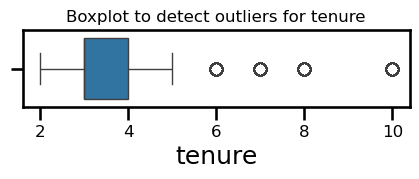

In [701]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(5, 1))
plt.title("Boxplot to detect outliers for tenure", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1["tenure"])
plt.show()

The boxplot shows some employees with unusually high tenure. These values should be reviewed before modeling.


Investigate how many rows in the data contain outliers in the `tenure` column.

In [702]:
# Compute the 25th percentile value in `tenure`
percentile25 = df1["tenure"].quantile(0.25)

# Compute the 75th percentile value in `tenure`
percentile75 = df1["tenure"].quantile(0.75)

# Compute the interquartile range in `tenure`
iqr = percentile75 - percentile25

# Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify subset of data containing outliers in `tenure`
outliers = df1[(df1["tenure"] > upper_limit) | (df1["tenure"] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print(
    "Number of rows in the data containing outliers in `tenure`:", len(outliers)
)

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


##### **Findings**

>The outlier limits for tenure are 1.5 and 5.5. There are 824 rows above the upper limit.


#### **Class Imbalance**
Determine how many employees left and what percentage they represent out of the total workforce.

In [703]:
# Get numbers of people who left vs. stayed
print(df1["left"].value_counts())
print()

# Get percentages of people who left vs. stayed
print(df1["left"].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


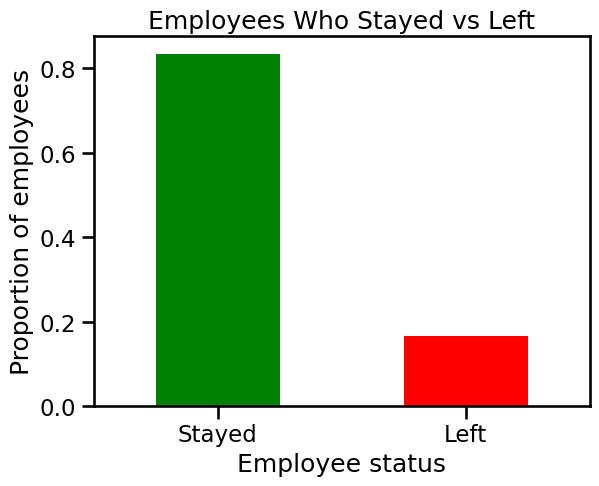

In [704]:
left_counts = (
    df1["left"].map({0: "Stayed", 1: "Left"}).value_counts(normalize=True)
)
ax = left_counts.plot.bar(color=["green", "red"])
ax.set_xlabel("Employee status")
ax.set_ylabel("Proportion of employees")
ax.set_title("Employees Who Stayed vs Left")
ax.tick_params(axis="x", rotation=0)

##### **Findings**

>Most employees stayed with the company. About 16.6% of employees left, so the target class is imbalanced.


### **Step 3. EDA**

#### `average_monthly_hours` vs `number_project`
- Visualize the distribution of `number_project` for employees who stayed versus those who left
- Visualize relationships between `average_monthly_hours` and `number_project` in employees who stayed versus those who left

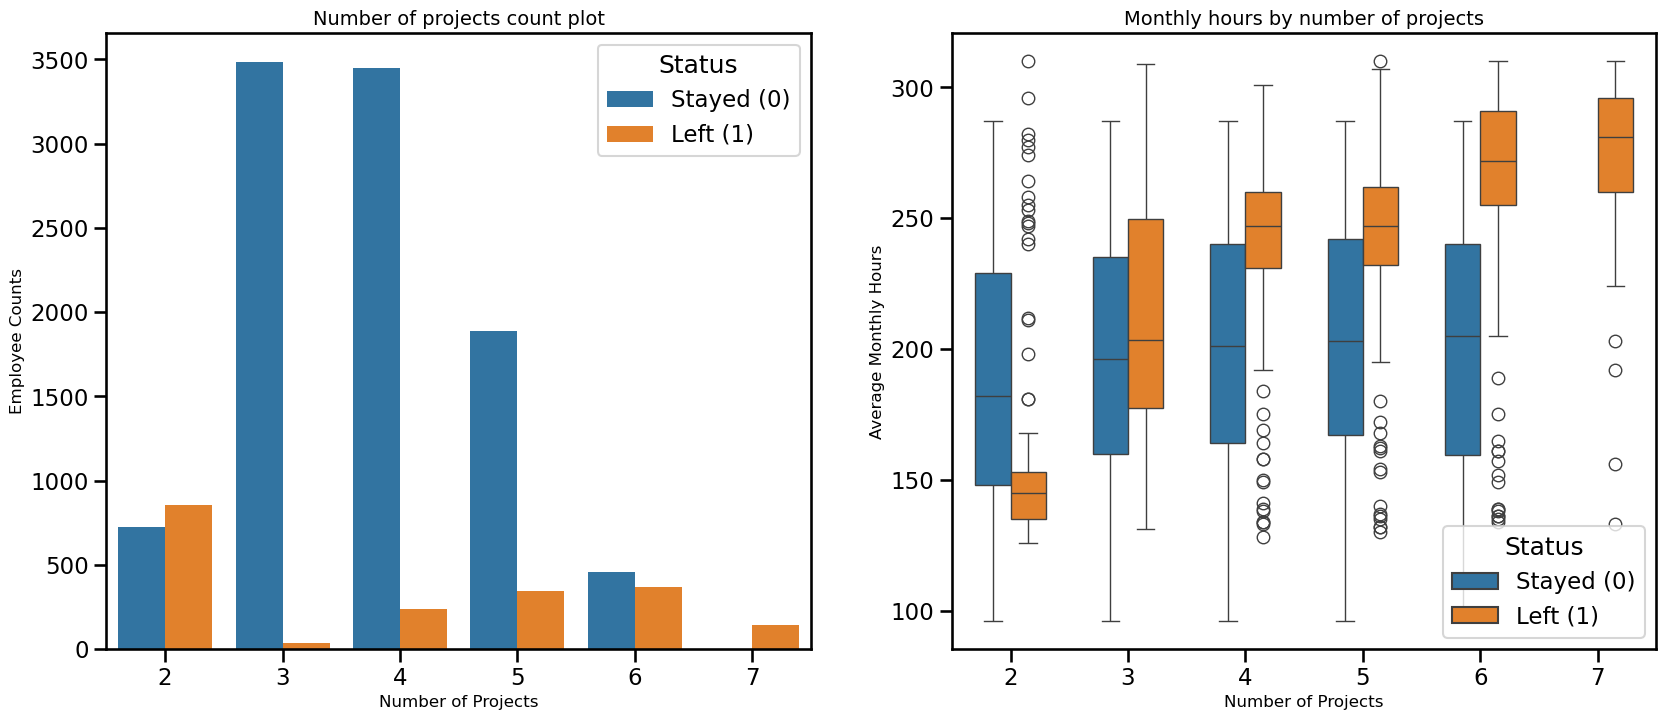

In [705]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Counts of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1["left"] == 0]["number_project"]
tenure_left = df1[df1["left"] == 1]["number_project"]

sns.countplot(data=df1, x="number_project", hue="left", ax=ax[0])
ax[0].set_title("Number of projects count plot", fontsize="14")
ax[0].set_xlabel("Number of Projects", fontsize=12)
ax[0].set_ylabel("Employee Counts", fontsize=12)
handles, labels = ax[0].get_legend_handles_labels()
# labels will be ['0', '1']
ax[0].legend(handles, ["Stayed (0)", "Left (1)"], title="Status")


# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(
    data=df1,
    y="average_monthly_hours",
    x="number_project",
    hue="left",
    width=0.6,
    ax=ax[1],
    legend=True,
)

ax[1].set_title("Monthly hours by number of projects", fontsize="14")
ax[1].set_xlabel("Number of Projects", fontsize=12)
ax[1].set_ylabel("Average Monthly Hours", fontsize=12)
handles, labels = ax[1].get_legend_handles_labels()
# labels will be ['0', '1']
ax[1].legend(handles, ["Stayed (0)", "Left (1)"], title="Status")

# Display the plots
plt.show()

##### **Findings:**
1. People with more projects tend to work more hours. This is expected: more projects → more work → more hours.
2. Employees with 3–4 projects are the most stable. Very few employees in these groups left, which may suggest a more balanced workload.
3. Employees handling 7 projects all left. The right plot shows that 100% of employees with 7 projects left the company, and their working hours were very high, around 255–295 hours per month.
4. The plot shows stronger difference between employees who stayed and employees who left appears at the two extremes:
   - Some employees who left worked much fewer hours than others with the same number of projects. This may include employees who were already disengaged, leaving soon, or receiving fewer tasks.
   - Some employees who left worked much more than their peers. This may point to overload or burnout.
5. Many employees worked more than a standard 40-hour week. Average monthly hours above about 166 hours suggest that heavy workloads may be common in this company.


In [706]:
# Get value counts of stayed/left for employees with 7 projects
df1[df1["number_project"] == 7]["left"].value_counts()

left
1    145
Name: count, dtype: int64

**Findings**
> This confirms that all employees with 7 projects did leave. 


#### `average_monthly_hours` vs `satisfaction_level`

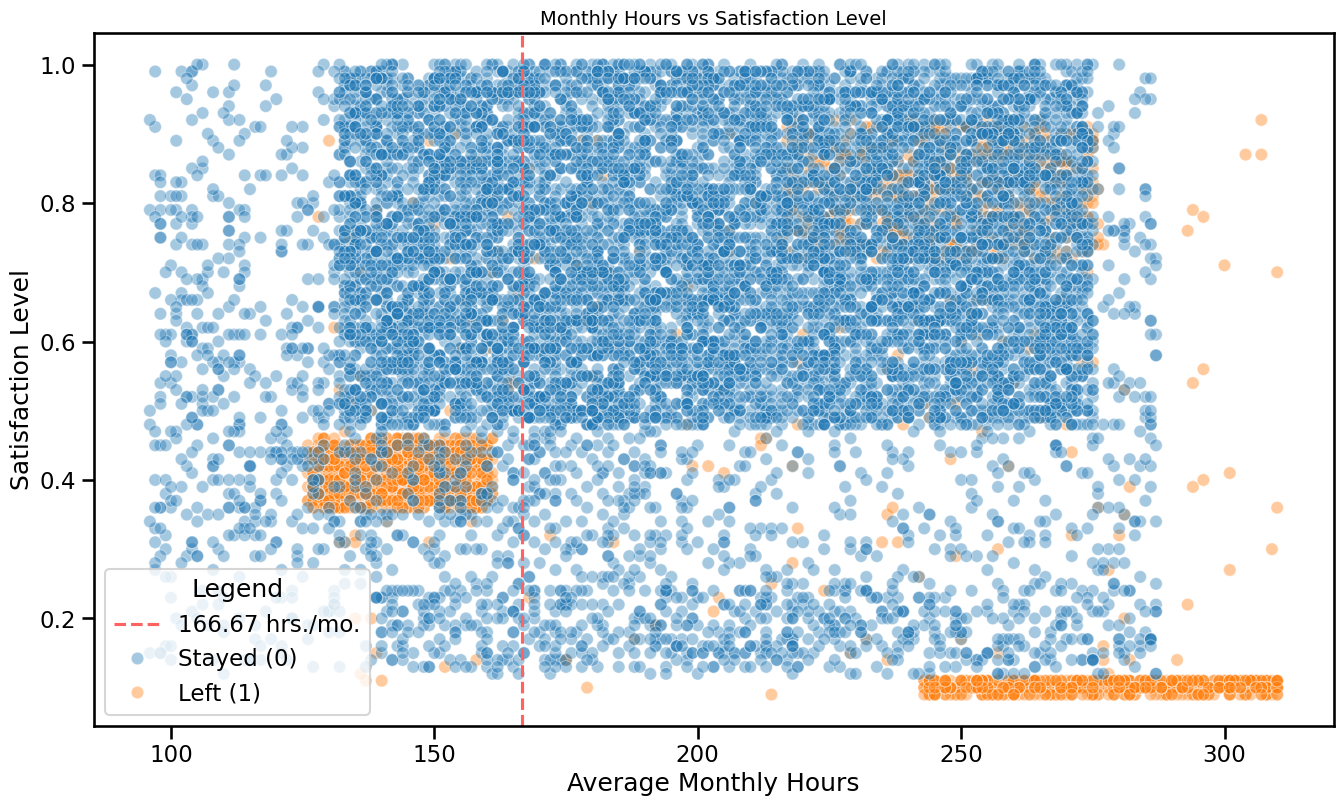

In [707]:
from matplotlib.lines import Line2D

plt.figure(figsize=(16, 9))

# Scatterplot
sns.scatterplot(
    data=df1,
    x="average_monthly_hours",
    y="satisfaction_level",
    hue="left",
    alpha=0.4,
)

# Vertical line (no label here)
plt.axvline(x=166.67, color="#ff6361", ls="--")

# Get the existing scatter legend handles/labels
handles, labels = plt.gca().get_legend_handles_labels()
# labels are usually ['0', '1']

# Create a custom line handle for the legend
line_handle = Line2D([0], [0], color="#ff6361", linestyle="--")

# Build new handles and labels
new_handles = [line_handle] + handles
new_labels = ["166.67 hrs./mo.", "Stayed (0)", "Left (1)"]

plt.legend(new_handles, new_labels, title="Legend")
plt.title("Monthly Hours vs Satisfaction Level", fontsize=14)
plt.xlabel("Average Monthly Hours")
plt.ylabel("Satisfaction Level")
plt.show()

##### **Findings:** 
1. A large left group worked extremely long hours (240–315 hours/month) and had near-zero satisfaction, suggesting overwork contributed to turnover.
2. Another left group left despite normal hours, but their satisfaction was still low (~0.4), possibly due to workplace pressure.
3. A third left group worked 210–280 hours/month and reported high satisfaction (0.7–0.9).
4. The unusual clustering patterns suggest the data may be synthetic or manipulated.

#### `satisfaction_level` vs `tenure`

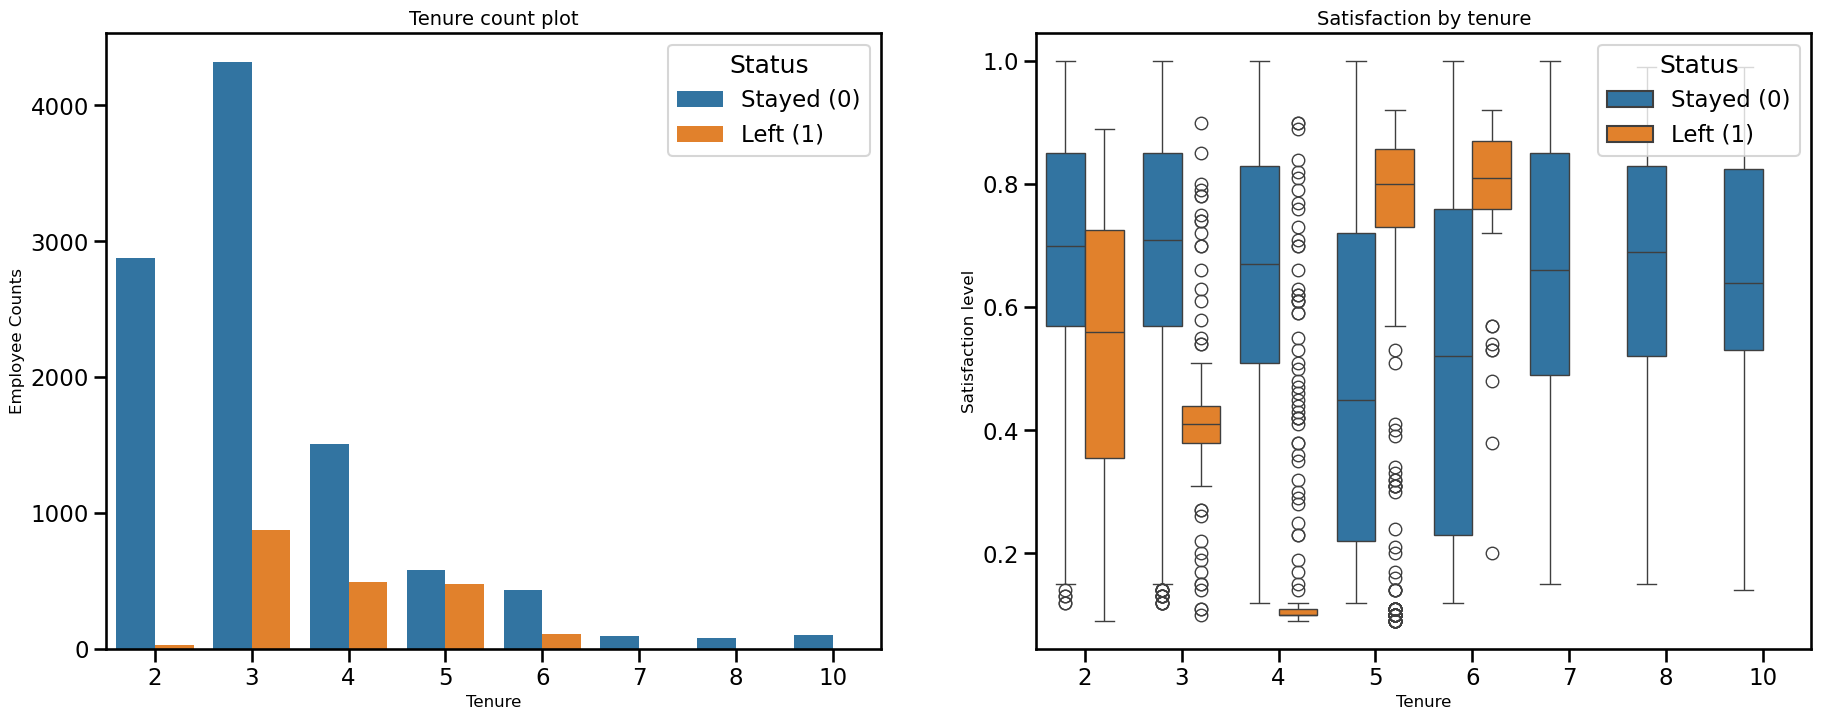

In [708]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize=(22, 8))
# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1["left"] == 0]["tenure"]
tenure_left = df1[df1["left"] == 1]["tenure"]
sns.countplot(data=df1, x="tenure", hue="left", ax=ax[0])
ax[0].set_title("Tenure count plot", fontsize="14")
ax[0].set_xlabel("Tenure", fontsize=12)
ax[0].set_ylabel("Employee Counts", fontsize=12)
handles, labels = ax[0].get_legend_handles_labels()
# labels will be ['0', '1']
ax[0].legend(handles, ["Stayed (0)", "Left (1)"], title="Status")

# Create boxplot showing distributions of `satisfaction_level` by tenure, comparing employees who stayed versus those who left
sns.boxplot(data=df1, y="satisfaction_level", x="tenure", hue="left", ax=ax[1])
ax[1].set_title("Satisfaction by tenure", fontsize="14")
ax[1].set_xlabel("Tenure", fontsize=12)
ax[1].set_ylabel("Satisfaction level", fontsize=12)
handles, labels = ax[1].get_legend_handles_labels()
# labels will be ['0', '1']
ax[1].legend(handles, ["Stayed (0)", "Left (1)"], title="Status")

plt.show()

##### **Findings:**
1. The countplot shows few long-tenured workers, possibly because they hold higher-level or better-paid positions.
2. Employees who left generally fall into two groups: those with short tenures and low satisfaction, and those with mid-level tenures and high satisfaction.
3. Four-year employees who left show unusually low satisfaction, suggesting a policy or milestone at that point may be worth investigating.
4. Long-tenured employees did not leave, and their satisfaction resembles that of newer employees who stayed.

In [709]:
# Calculate mean and median satisfaction scores of employees who left and those who stayed
df1.groupby(["left"])["satisfaction_level"].agg(["mean", "median"])

,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


**Findings**
>The mean and median satisfaction scores are lower for employees who left, as expected. Among those who stayed, the mean is slightly below the median, suggesting their satisfaction distribution is left-skewed.

#### `tenure` vs `salary`

Text(0.5, 1.0, 'Salary histogram by tenure: long-tenured people')

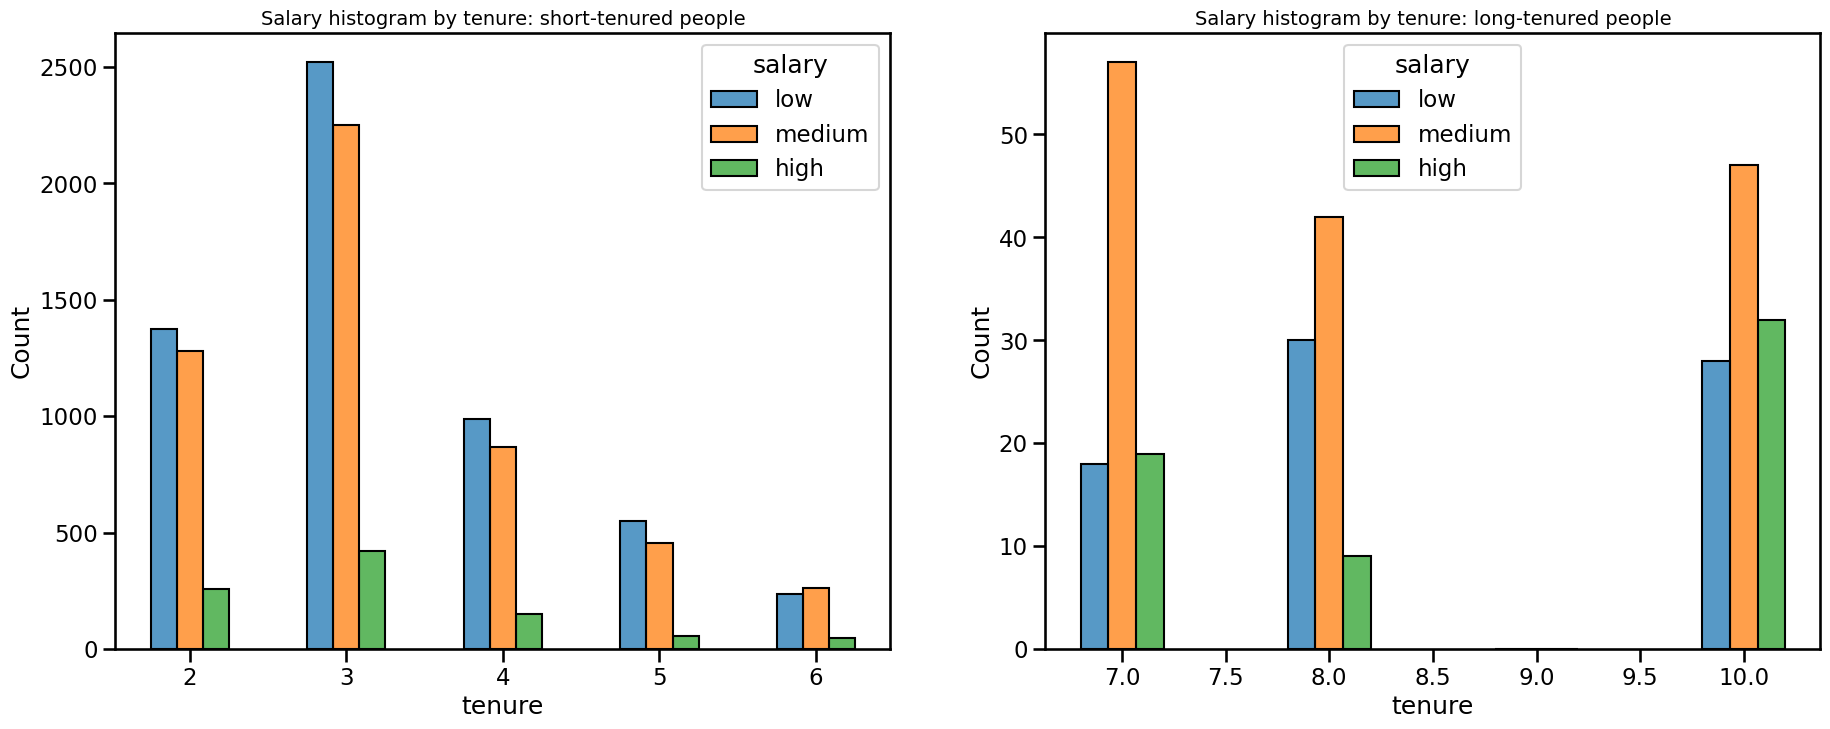

In [710]:
# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# Define short-tenured employees
tenure_short = df1[df1["tenure"] < 7]

# Define long-tenured employees
tenure_long = df1[df1["tenure"] > 6]

# Plot short-tenured histogram
sns.histplot(
    data=tenure_short,
    x="tenure",
    hue="salary",
    discrete=1,
    hue_order=["low", "medium", "high"],
    multiple="dodge",
    shrink=0.5,
    ax=ax[0],
)
ax[0].set_title(
    "Salary histogram by tenure: short-tenured people", fontsize="14"
)

# Plot long-tenured histogram
sns.histplot(
    data=tenure_long,
    x="tenure",
    hue="salary",
    discrete=1,
    hue_order=["low", "medium", "high"],
    multiple="dodge",
    shrink=0.4,
    ax=ax[1],
)
ax[1].set_title(
    "Salary histogram by tenure: long-tenured people", fontsize="14"
)

##### **Findings**
>The plots above show that long-tenured employees were not disproportionately comprised of higher-paid employees. 


#### `average_monthly_hours` versus `last_evaluation`.

Text(0, 0.5, 'Last Evaluation')

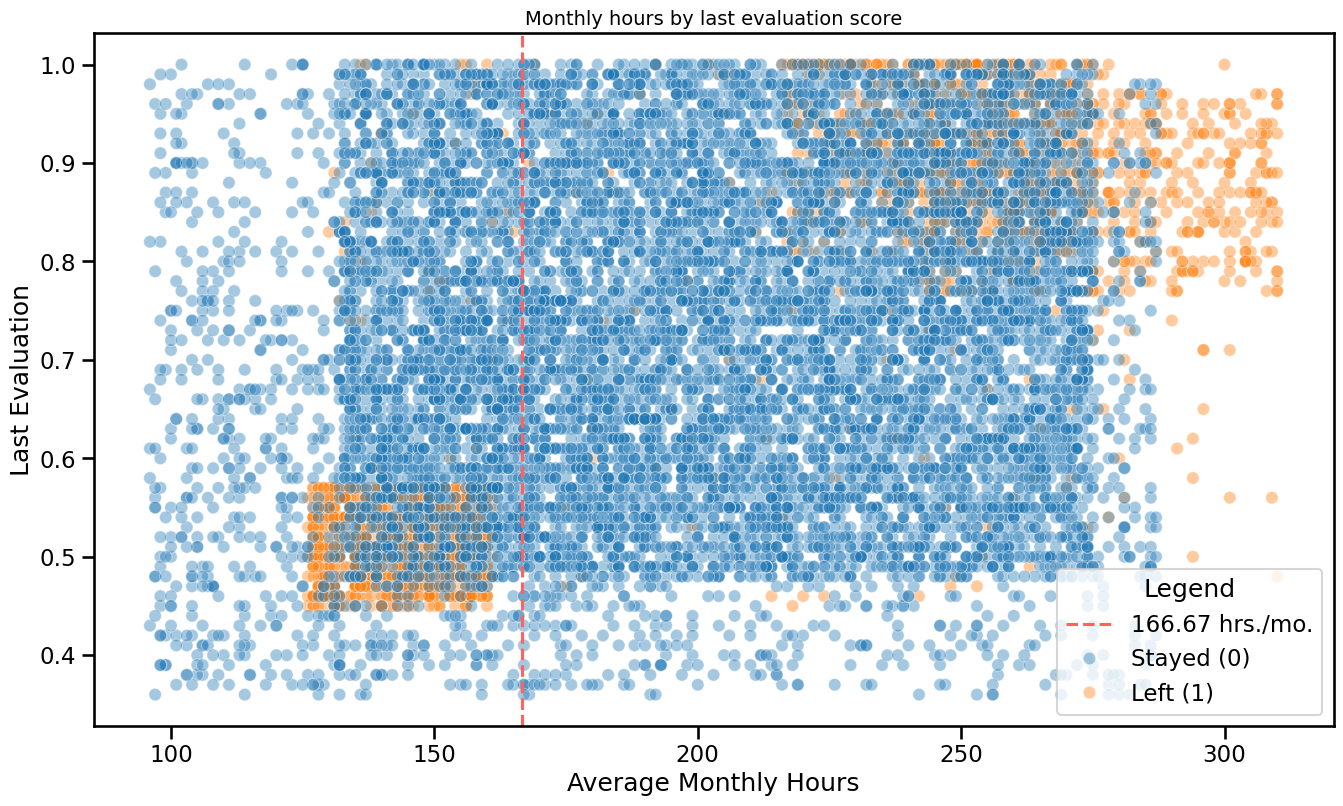

In [711]:
# Create a plot as needed
# Create scatterplot of `average_monthly_hours` versus `last_evaluation`
plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=df1,
    x="average_monthly_hours",
    y="last_evaluation",
    hue="left",
    alpha=0.4,
)
plt.axvline(x=166.67, color="#ff6361", label="166.67 hrs./mo.", ls="--")
# Get the existing scatter legend handles/labels
handles, labels = plt.gca().get_legend_handles_labels()
# labels are usually ['0', '1']

# Create a custom line handle for the legend
line_handle = Line2D([0], [0], color="#ff6361", linestyle="--")

# Build new handles and labels
new_handles = [line_handle] + handles
new_labels = ["166.67 hrs./mo.", "Stayed (0)", "Left (1)"]
plt.legend(new_handles, new_labels, title="Legend")
plt.title("Monthly hours by last evaluation score", fontsize="14")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Last Evaluation")

##### **Findings:**
>1. The scatterplot shows two groups of employees who left: highly overworked high performers and lower-performing employees who worked slightly below the nominal 166.67 hours.
>2. Hours worked and evaluation scores appear correlated, but long hours do not guarantee strong evaluations.
>3. Few employees fall in the upper-left quadrant (high hours, low evaluation).
>4. Most employees work well above 167 hours per month.

#### `average_monthly_hours` vs `promotion_last_5years`

Text(0, 0.5, 'Promotion last 5 years')

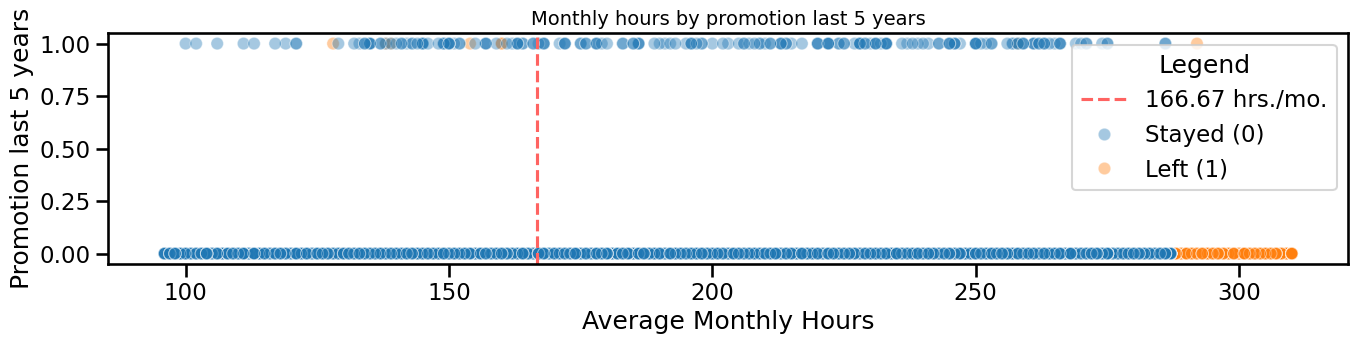

In [712]:
# Create plot to examine relationship between `average_monthly_hours` and `promotion_last_5years`
plt.figure(figsize=(16, 3))
sns.scatterplot(
    data=df1,
    x="average_monthly_hours",
    y="promotion_last_5years",
    hue="left",
    alpha=0.4,
)
plt.axvline(x=166.67, color="#ff6361", label="166.67 hrs./mo.", ls="--")
# Get the existing scatter legend handles/labels
handles, labels = plt.gca().get_legend_handles_labels()
# labels are usually ['0', '1']

# Create a custom line handle for the legend
line_handle = Line2D([0], [0], color="#ff6361", linestyle="--")

# Build new handles and labels
new_handles = [line_handle] + handles
new_labels = ["166.67 hrs./mo.", "Stayed (0)", "Left (1)"]
plt.legend(new_handles, new_labels, title="Legend")
plt.title("Monthly hours by promotion last 5 years", fontsize="14")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Promotion last 5 years")

##### **Findings:**
>- very few employees who were promoted in the last five years left
>- very few employees who worked the most hours were promoted
>- all of the employees who left were working the longest hours  


#### `left` vs `department`

In [713]:
# Display counts for each department
df1["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

Sales, technical, and support have the most employees. Smaller departments such as management and HR have fewer records.


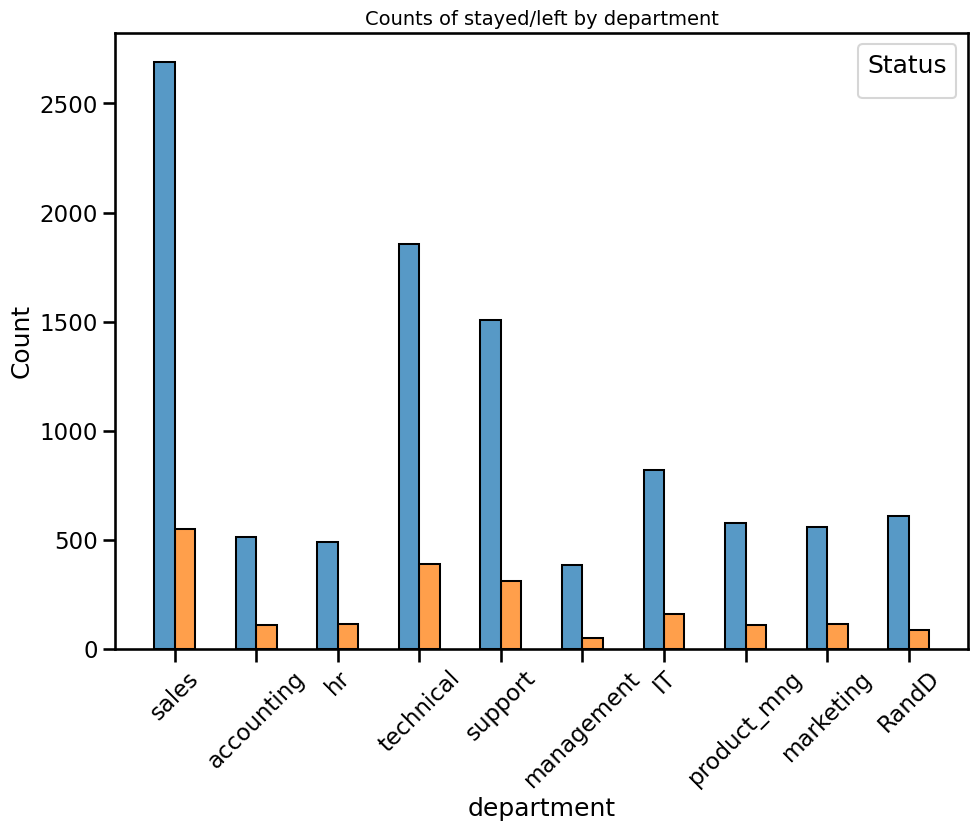

In [714]:
# Create a plot as needed
# Create stacked histogram to compare department distribution of employees who left to that of employees who didn't
plt.figure(figsize=(11, 8))
sns.histplot(
    data=df1,
    x="department",
    hue="left",
    discrete=1,
    hue_order=[0, 1],
    multiple="dodge",
    shrink=0.5,
)
plt.xticks(rotation=45)
plt.title("Counts of stayed/left by department", fontsize=14)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["Stayed (0)", "Left (1)"], title="Status")

In [715]:
# Display attrition rate by department
department_attrition_rate = (
    df1.groupby("department")["left"].mean().sort_values(ascending=False)
)

department_attrition_rate

department
hr             0.188020
accounting     0.175523
technical      0.173797
support        0.171334
sales          0.169805
marketing      0.166419
IT             0.161885
product_mng    0.160350
RandD          0.122478
management     0.119266
Name: left, dtype: float64


The department plot does not show one department with a clearly unusual attrition pattern. Attrition appears spread across departments.


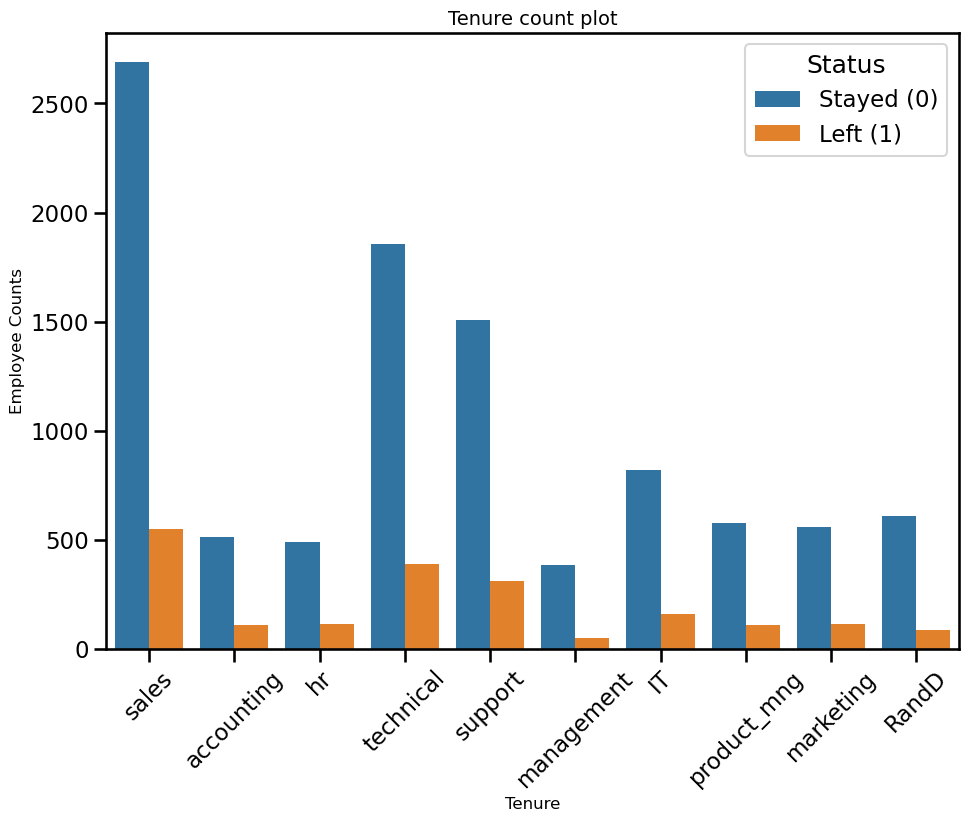

In [716]:
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
# Create histogram showing distribution of `tenure`, comparing employees who stayed versus those who left
sns.countplot(data=df1, x="department", hue="left", ax=ax)
ax.set_title("Tenure count plot", fontsize="14")
plt.xticks(rotation=45)
ax.set_xlabel("Tenure", fontsize=12)
ax.set_ylabel("Employee Counts", fontsize=12)
handles, labels = ax.get_legend_handles_labels()
# labels will be ['0', '1']
ax.legend(handles, ["Stayed (0)", "Left (1)"], title="Status")

##### **Findings**

- There doesn't seem to be any department that differs significantly in its proportion of employees who left to those who stayed. 
- The tenure plot shows that attrition is more connected to tenure patterns than to department alone.





#### **Correlation matrix**

Text(0.5, 1.0, 'Correlation Heatmap')

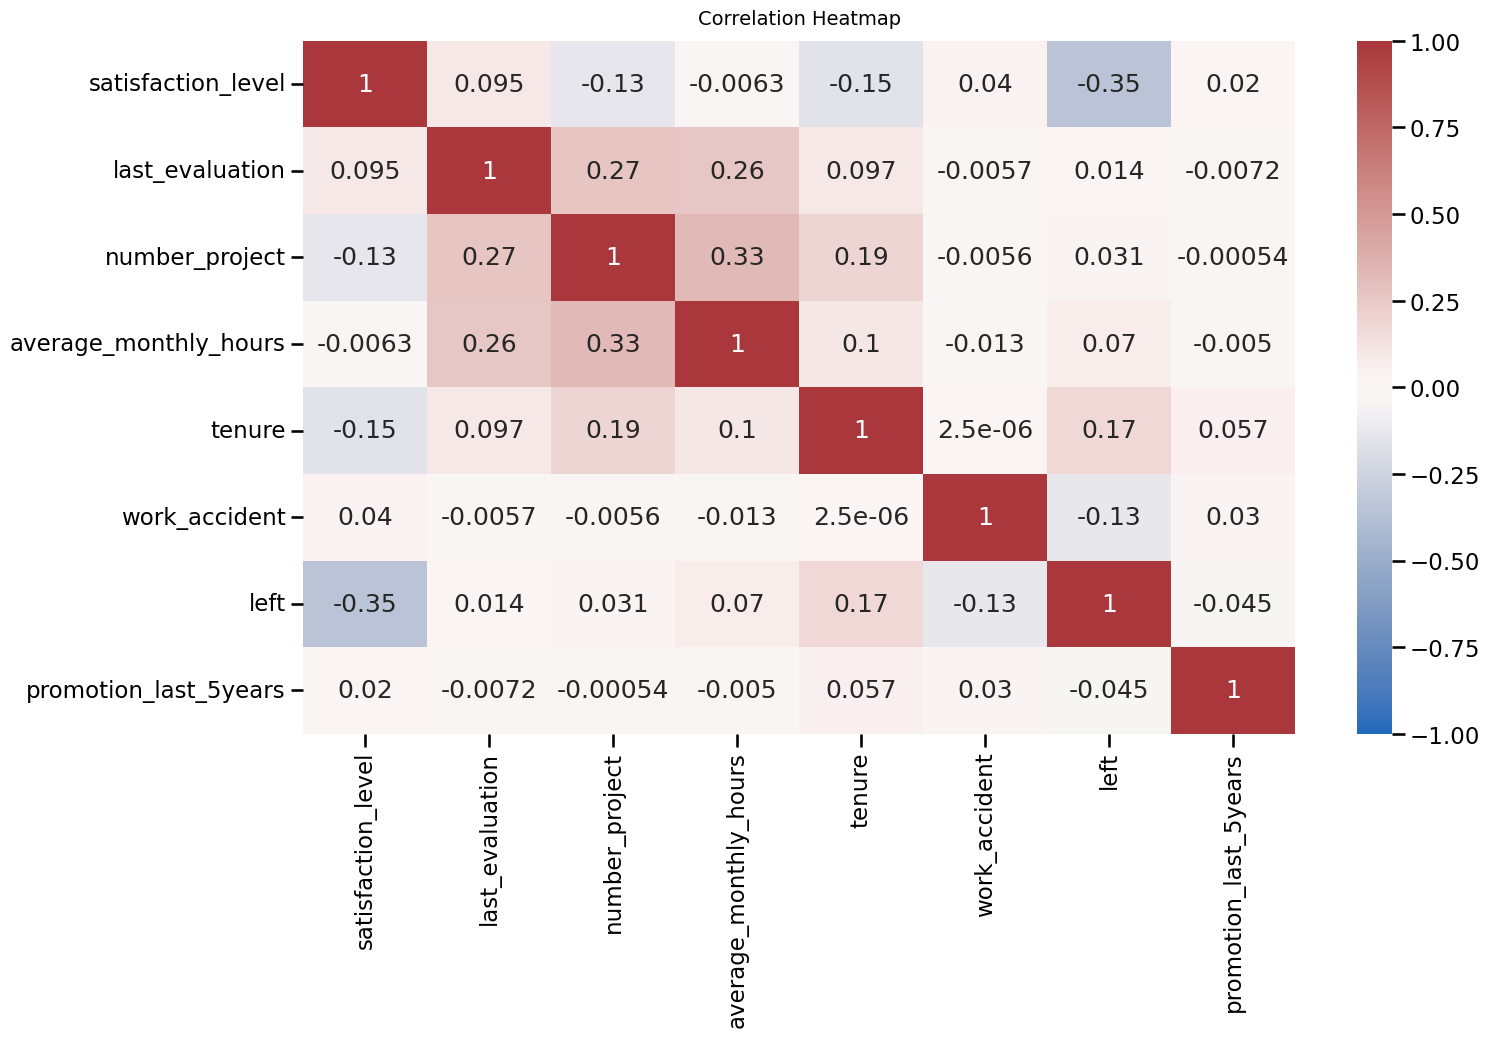

In [717]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(
    df1.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap=sns.color_palette("vlag", as_cmap=True),
)
heatmap.set_title("Correlation Heatmap", fontdict={"fontsize": 14}, pad=12)

##### **Findings**

The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.


#### **Summary**
>Employees seem to be leaving the company because of poor management. Those who leave tend to work long hours, handle many projects, and report low satisfaction. Many are likely burned out, especially if they work a lot but don’t receive promotions or strong evaluations. On the other hand, employees who have been with the company for more than six years rarely leave.

## **Model Development**
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### **Data Pre-processing**

In [718]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.0+ MB


After removing duplicates, the cleaned dataframe has 11,991 rows and 10 columns. The column types are ready for encoding and modeling.


#### **Featrure Characterization**
Some numeric-looking columns are actually binary indicators, and some text columns are categorical labels. To define feature groups, check both the column meaning and the number of unique values.


In [719]:
# Review each column's dtype and unique values to decide how it should be preprocessed
feature_profile = pd.DataFrame(
    {
        "dtype": df1.dtypes.astype(str),
        "n_unique": df1.nunique(),
        "sample_values": [
            (
                sorted(df1[col].dropna().unique().tolist())
                if df1[col].nunique() <= 10
                else "many values"
            )
            for col in df1.columns
        ],
    }
)

feature_profile

,dtype,n_unique,sample_values
satisfaction_level,float64,92,many values
last_evaluation,float64,65,many values
number_project,int64,6,"[2, 3, 4, 5, 6, 7]"
average_monthly_hours,int64,215,many values
tenure,int64,8,"[2, 3, 4, 5, 6, 7, 8, 10]"
work_accident,int64,2,"[0, 1]"
left,int64,2,"[0, 1]"
promotion_last_5years,int64,2,"[0, 1]"
department,object,10,"[IT, RandD, accounting, hr, management, market..."
salary,object,3,"[high, low, medium]"


- `satisfaction_level`, `last_evaluation`, `number_project`, `average_monthly_hours`, and `tenure` are numeric features because they measure an amount, score, count, or time value.
- `work_accident` and `promotion_last_5years` are binary features because they only contain 0 and 1. Even though they are stored as integers, they represent yes/no indicators.
- `department` and `salary` are categorical features because they represent groups or labels. `salary` has an order in real life, but this pipeline uses one-hot encoding to avoid forcing a linear distance between low, medium, and high salary.
- `left` is not included as a feature because it is the target variable the model predicts.


#### **Column Definitions**

`left` is the outcome variable that the models will predict. A value of 1 means the employee left the company. 

In [720]:
target_col = "left"

numeric_features = [
    "satisfaction_level",
    "last_evaluation",
    "number_project",
    "average_monthly_hours",
    "tenure",
]

binary_features = [
    "work_accident",
    "promotion_last_5years",
]

categorical_features = [
    "department",
    "salary",
]

# ------------------ Sanity check ------------------ #
expected = (
    numeric_features + binary_features + categorical_features + [target_col]
)
missing = [c for c in expected if c not in df1.columns]
if missing:
    raise ValueError(f"Missing expected columns in df1: {missing}")

#### **Train Test Split**

In [721]:
# Select numeric, binary, and categorical features from dataframe df1
X = df1[numeric_features + binary_features + categorical_features].copy()

# Convert target variable to integer type
y = df1[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

#### **Feature Encoding**
The raw dataset contains numeric, binary, and categorical features, so different preprocessing steps are required for different variable types. To handle this consistently, a `ColumnTransformer` is used inside each model pipeline. Integrating preprocessing directly into the pipeline ensures that all transformations are learned only from the training data during model fitting, which helps prevent data leakage.

Encoding plan:

- Numeric features: passed through unchanged by default. When `USE_SCALER = True`, numeric variables are standardized using StandardScaler to place features on a comparable scale. (regularization is sensitive to feature scale.)
- Binary features: passed through unchanged because they are already represented as 0/1 values and do not require additional encoding.
- Categorical features: transformed using `OneHotEncoder`, which creates separate indicator columns for each category. This avoids introducing artificial ordinal relationships between categories such as departments or device types.

The same `preprocessor` object can then be reused across multiple machine learning pipelines, including logistic regression, KNN, SVM, tree-based models, and ensemble methods, ensuring consistent preprocessing across all models.

In [722]:
def make_preprocessor(
    numeric_cols, binary_cols, categorical_cols, use_scaler=False
):
    numeric_transformer = (
        Pipeline([("scaler", StandardScaler())])
        if use_scaler
        else "passthrough"
    )

    categorical_transformer = OneHotEncoder(handle_unknown="ignore")

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("bin", "passthrough", binary_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
    )


# Main preprocessor used by models with the original feature set
USE_SCALER = False
preprocessor = make_preprocessor(
    numeric_features,
    binary_features,
    categorical_features,
    use_scaler=USE_SCALER,
)

We used a `ColumnTransformer` within the model pipeline to encode categorical features. The model receives the original feature dataframe X, while all preprocessing steps are automatically applied during `.fit()` and `.predict()`.

This pipeline-based approach is preferred because:

- Encoding rules are learned only from the training data, helping prevent data leakage.
- The test data is transformed using the same categories learned from the training set, ensuring consistency.
- Unseen categories in the test data can be handled safely using `handle_unknown='ignore'`.


In [723]:
# Preview the transformed feature matrix for documentation only.
# Model cells below keep this transformer inside each pipeline.
X_train_preview = preprocessor.fit_transform(X_train)
X_test_preview = preprocessor.transform(X_test)

if sparse.issparse(X_train_preview):
    X_train_preview = X_train_preview.toarray()
    X_test_preview = X_test_preview.toarray()

feature_names = preprocessor.get_feature_names_out()

X_train_preview_df = pd.DataFrame(
    X_train_preview, columns=feature_names, index=X_train.index
)

print(
    "Train shape:",
    X_train_preview_df.shape,
    "| Test shape:",
    X_test_preview.shape,
)
print(
    "Positive rate (train/test):", f"{y_train.mean():.3f} / {y_test.mean():.3f}"
)
print("Example encoded features:", list(feature_names[:8]))

X_train_preview_df.head()

Train shape: (9592, 20) | Test shape: (2399, 20)
Positive rate (train/test): 0.166 / 0.166
Example encoded features: ['num__satisfaction_level', 'num__last_evaluation', 'num__number_project', 'num__average_monthly_hours', 'num__tenure', 'bin__work_accident', 'bin__promotion_last_5years', 'cat__department_IT']


,num__satisfaction_level,num__last_evaluation,num__number_project,num__average_monthly_hours,num__tenure,bin__work_accident,bin__promotion_last_5years,cat__department_IT,cat__department_RandD,cat__department_accounting,cat__department_hr,cat__department_management,cat__department_marketing,cat__department_product_mng,cat__department_sales,cat__department_support,cat__department_technical,cat__salary_high,cat__salary_low,cat__salary_medium
2041,0.98,0.91,4.0,240.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10444,0.63,0.89,3.0,239.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2030,0.85,0.59,3.0,235.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
11606,0.56,0.39,3.0,106.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2008,0.50,0.75,6.0,127.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### **Logistic Regression Model**
#### **Build Basic and Regularization Models**

Construct three logistic regression pipelines and tune them with `GridSearchCV`. 
Because this is a classification problem, we use <code>StratifiedKFold</code> for cross-validation. It shuffles the data before making the folds and keeps the class proportions similar in each fold.


In [724]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

# Standard logistic regression pipeline with GridSearchCV
logreg_base_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                random_state=42,
                max_iter=500,
            ),
        ),
    ]
)

log_clf = GridSearchCV(
    estimator=logreg_base_pipeline,
    param_grid={
        "model__penalty": ["l2"],
        "model__C": [1.0],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

log_clf.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [1.0], 'model__penalty': ['l2']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


In [725]:
# L1 regularized logistic regression pipeline with GridSearchCV
logreg_l1_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                penalty="l1",
                solver="liblinear",
                random_state=42,
                max_iter=500,
            ),
        ),
    ]
)

log_clf_l1 = GridSearchCV(
    estimator=logreg_l1_pipeline,
    param_grid={
        "model__C": [0.01, 0.1, 1, 10, 100],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

log_clf_l1.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


The L1 regularized logistic regression model was tuned with `GridSearchCV`. This searches different values of `C` and selects the model with the best cross-validated ROC AUC.


In [726]:
# L2 regularized logistic regression pipeline with GridSearchCV
logreg_l2_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                penalty="l2",
                solver="liblinear",
                random_state=42,
                max_iter=500,
            ),
        ),
    ]
)

log_clf_l2 = GridSearchCV(
    estimator=logreg_l2_pipeline,
    param_grid={
        "model__C": [0.01, 0.1, 1, 10, 100],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

log_clf_l2.fit(X_train, y_train)

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


The L2 regularized logistic regression model was tuned with `GridSearchCV`. This uses the same cross-validation workflow as the later decision tree and random forest models.


Test the logistic regression model: use the model to make predictions on the test set.

In [727]:
y_pred = list()
y_prob = list()

coeff_labels = ["log_clf", "log_clf_l1", "log_clf_l2"]
coeff_models = [log_clf, log_clf_l1, log_clf_l2]

for lab, mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test)[:, 1], name=lab))

y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_prob.head()

,log_clf,log_clf_l1,log_clf_l2
0,0.102145,0.107976,0.108596
1,0.733271,0.721945,0.726889
2,0.839514,0.828282,0.833979
3,0.125140,0.127012,0.127945
4,0.867342,0.861298,0.863963


The table shows predicted probabilities from the logistic regression models. The three models give very similar probability estimates.


In [728]:
y_pred.head()

,log_clf,log_clf_l1,log_clf_l2
0,0,0,0
1,1,1,1
2,1,1,1
3,0,0,0
4,1,1,1


The prediction table shows the class predictions from each logistic regression model. The models mostly agree on the same predictions.


#### **Metrics Evaluation**
Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [729]:
results = {}
cm = {}

for lab in coeff_labels:
    # Preciision, recall, f-score
    precision, recall, fscore, support = precision_recall_fscore_support(
        y_test, y_pred[lab], average=None
    )

    results[lab] = {
        # class 0（not leave）
        "precision_not_leave": precision[0],
        "recall_not_leave": recall[0],
        "f1_not_leave": fscore[0],
        # class 1（leave）
        "precision_1_leave": precision[1],
        "recall_1_leave": recall[1],
        "f1_1_leave": fscore[1],
        # both classes
        "accuracy": accuracy_score(y_test, y_pred[lab]),
        "auc": roc_auc_score(y_test, y_prob[lab]),
    }

    # Last, the confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab], normalize="true")

metrics = pd.DataFrame.from_dict(results, orient="index")
metrics

,precision_not_leave,recall_not_leave,f1_not_leave,precision_1_leave,recall_1_leave,f1_1_leave,accuracy,auc
log_clf,0.961657,0.777111,0.859591,0.429668,0.844221,0.569492,0.788245,0.848269
log_clf_l1,0.961994,0.771614,0.856351,0.424433,0.846734,0.565436,0.784077,0.848156
log_clf_l2,0.960918,0.774113,0.857459,0.425667,0.841709,0.565401,0.785327,0.848345


In [730]:
log_clf_preds = log_clf.predict(X_test)
print(
    "Standard Logistic Regression:\n",
    classification_report(
        y_test, log_clf_preds, target_names=["Stayed", "Left"]
    ),
)

log_clf_l1_preds = log_clf_l1.predict(X_test)
print(
    "Logistic Regression with L1 Regularization:\n",
    classification_report(
        y_test, log_clf_l1_preds, target_names=["Stayed", "Left"]
    ),
)

log_clf_l2_preds = log_clf_l2.predict(X_test)
print(
    "Logistic Regression with L2 Regularization:\n",
    classification_report(
        y_test, log_clf_l2_preds, target_names=["Stayed", "Left"]
    ),
)

Standard Logistic Regression:
               precision    recall  f1-score   support

      Stayed       0.96      0.78      0.86      2001
        Left       0.43      0.84      0.57       398

    accuracy                           0.79      2399
   macro avg       0.70      0.81      0.71      2399
weighted avg       0.87      0.79      0.81      2399

Logistic Regression with L1 Regularization:
               precision    recall  f1-score   support

      Stayed       0.96      0.77      0.86      2001
        Left       0.42      0.85      0.57       398

    accuracy                           0.78      2399
   macro avg       0.69      0.81      0.71      2399
weighted avg       0.87      0.78      0.81      2399

Logistic Regression with L2 Regularization:
               precision    recall  f1-score   support

      Stayed       0.96      0.77      0.86      2001
        Left       0.43      0.84      0.57       398

    accuracy                           0.79      2399
   macr

In [731]:
log_clf.predict_proba(X_test)

array([[0.89785499, 0.10214501],
       [0.26672909, 0.73327091],
       [0.1604862 , 0.8395138 ],
       ...,
       [0.67763161, 0.32236839],
       [0.00440163, 0.99559837],
       [0.16751737, 0.83248263]])

#### **Confusion Matrix**
Create a confusion matrix to visualize the results of the logistic regression model. 

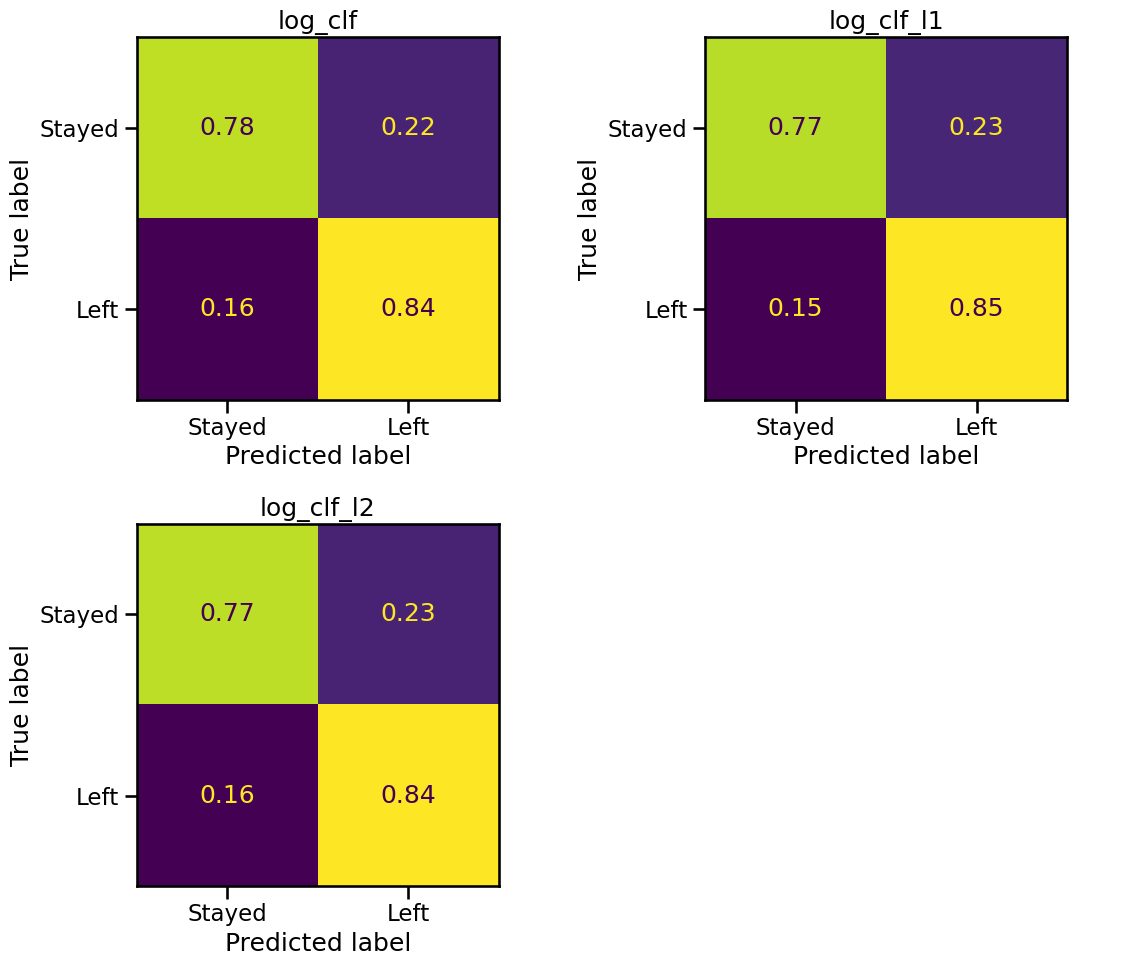

In [732]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, lab in zip(axes, coeff_labels):

    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred[lab], normalize="true"),
        display_labels=["Stayed", "Left"],
    ).plot(ax=ax, colorbar=False)

    ax.set_title(lab)

# Hide unused subplot
axes[-1].axis("off")

plt.tight_layout()
plt.show()

The three logistic regression models (log_clf, log_clf_l1, and log_clf_l2) produced very similar results, indicating that L1 and L2 regularization had minimal impact on overall performance.

- Approximately 77–78% of employees who stayed were correctly classified as stayed.
- Approximately 84–85% of employees who left were correctly identified as left.
- The models were slightly better at detecting employee turnover (`left`) than predicting retention (`stayed`).
- Misclassification rates were relatively stable across all models, with about 22–23% of employees who stayed incorrectly predicted to leave and about 15–16% of employees who left incorrectly predicted to stay.

Overall, the models achieved strong and stable classification performance, with only minor differences between the regularization methods.

#### **AUC/ROC**

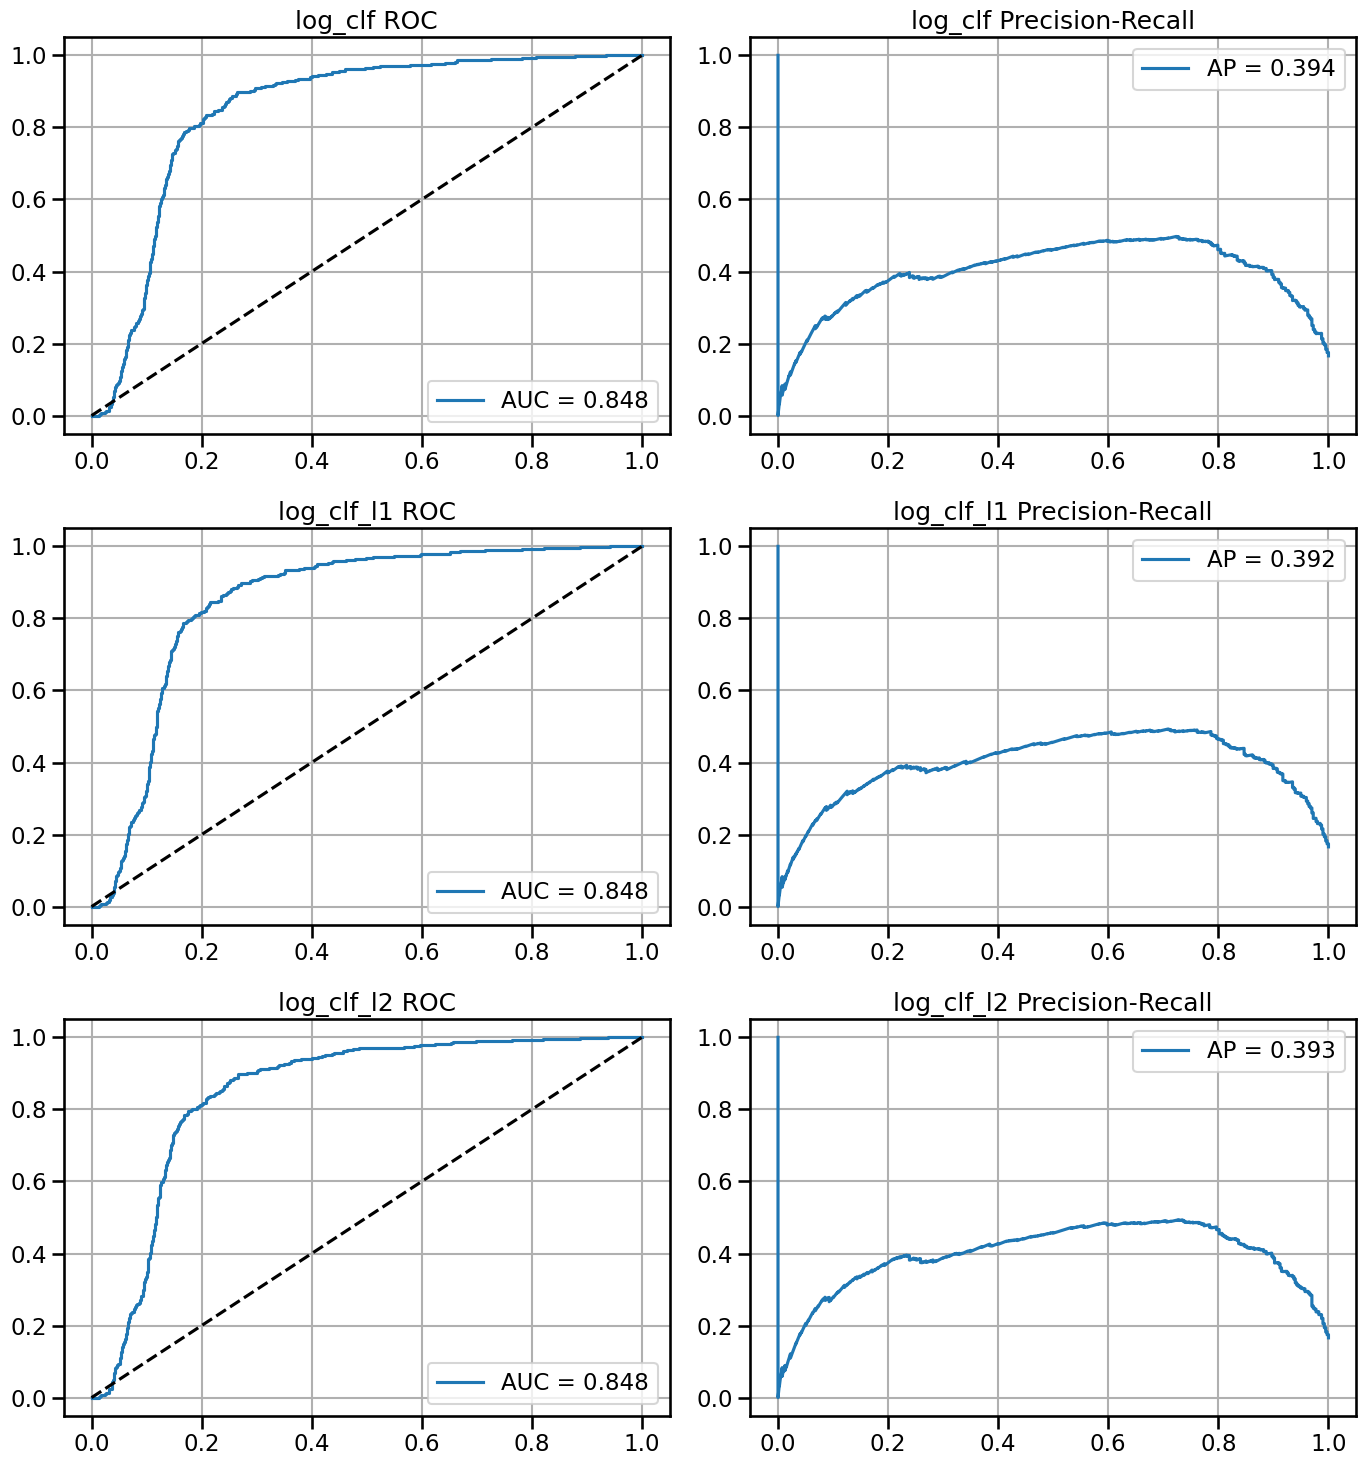

In [733]:
fig, axes = plt.subplots(
    len(coeff_models), 2, figsize=(14, 5 * len(coeff_models))
)

for i, (label, model) in enumerate(zip(coeff_labels, coeff_models)):

    y_score = model.predict_proba(X_test)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[i, 0].plot(
        fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_score):.3f}"
    )
    axes[i, 0].plot([0, 1], [0, 1], "--", color="black")
    axes[i, 0].set_title(f"{label} ROC")
    axes[i, 0].legend()
    axes[i, 0].grid(True)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    axes[i, 1].plot(recall, precision, label=f"AP = {ap:.3f}")
    axes[i, 1].set_title(f"{label} Precision-Recall")
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

- All three logistic regression models showed nearly identical ROC and PR curves, indicating that L1 and L2 regularization had minimal impact on overall ranking performance.
- ROC-AUC (~0.85) demonstrated strong ability to distinguish employees who left from those who stayed across different classification thresholds.
- The Precision-Recall curves revealed the effect of class imbalance more clearly, showing that precision decreases as recall increases.
- The curves also highlighted the tradeoff between detecting more employees likely to leave and increasing false positive predictions, which is not visible from the confusion matrices alone.

#### **Model Interpretation**

In [734]:
def plot_coefs(models, labels, columns):

    fig, axes = plt.subplots(len(models), 1, figsize=(8, 4 * len(models)))

    if len(models) == 1:
        axes = [axes]

    for ax, model, label in zip(axes, models, labels):

        coefs = model.best_estimator_.named_steps["model"].coef_[0]

        coef_dict = {f: c for f, c in zip(columns, coefs) if abs(c) >= 0.01}

        coef_dict = dict(sorted(coef_dict.items(), key=lambda x: x[1]))

        colors = ["red" if v < 0 else "green" for v in coef_dict.values()]

        ax.barh(list(coef_dict.keys()), list(coef_dict.values()), color=colors)

        ax.axvline(0, color="black")
        ax.set_title(label)

    plt.tight_layout()
    plt.show()

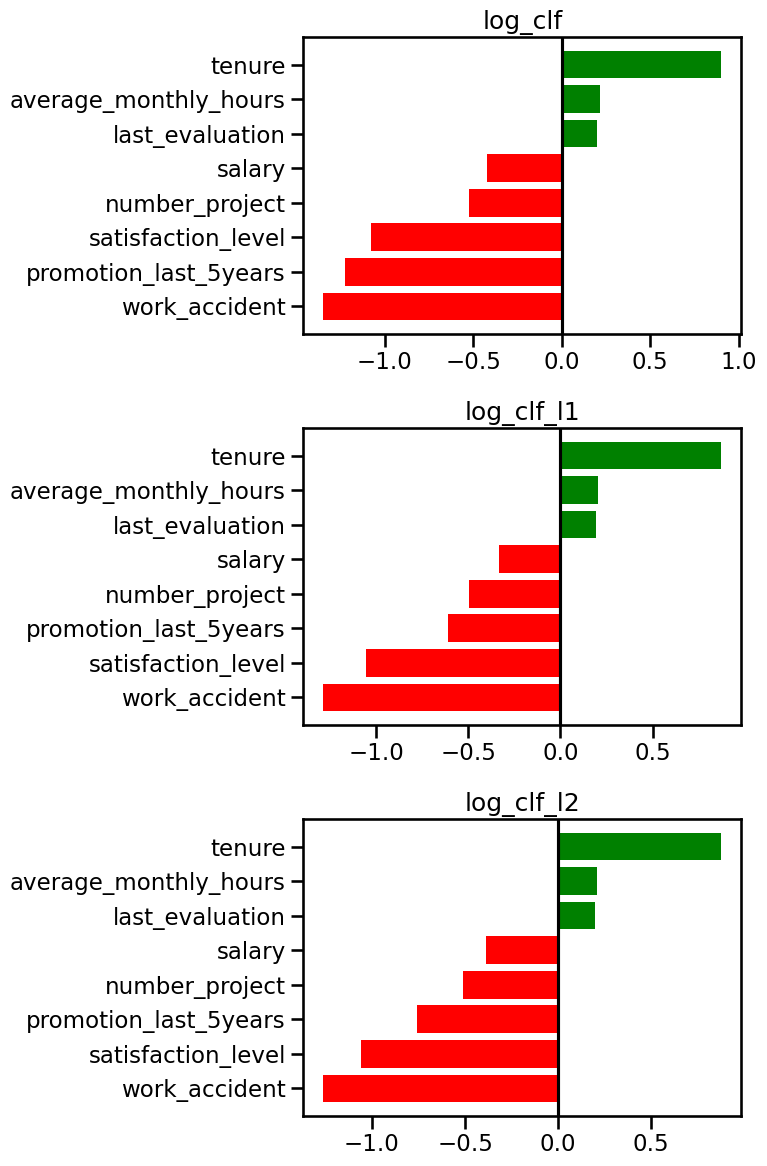

In [735]:
plot_coefs(coeff_models, coeff_labels, X_train.columns)


The coefficient plots showed highly consistent patterns across all three logistic regression models, indicating that L1 and L2 regularization had minimal impact on feature importance rankings.

- `promotion_last_5years` had the strongest positive coefficient, suggesting employees with recent promotions were more likely to stay (less likely to leave).
- `department`, `salary`, and `last_evaluation` showed the largest negative coefficients, indicating stronger association with employee turnover.
- `tenure` also had a moderate negative relationship with retention.
- `number_project` and `work_accident` had relatively small positive effects.

Overall, the models identified similar key drivers of employee turnover and retention, with only minor differences in coefficient magnitude across regularization methods.

### **KNN Model**

KNN is distance-based, so this pipeline scales numeric features after encoding categorical features.

In [736]:
knn_model = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=True,
            ),
        ),
        ("model", KNeighborsClassifier(n_neighbors=7, weights="distance")),
    ]
)

knn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [737]:
knn_preds = knn_model.predict(X_test)
print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2001
           1       0.83      0.92      0.87       398

    accuracy                           0.96      2399
   macro avg       0.91      0.94      0.92      2399
weighted avg       0.96      0.96      0.96      2399



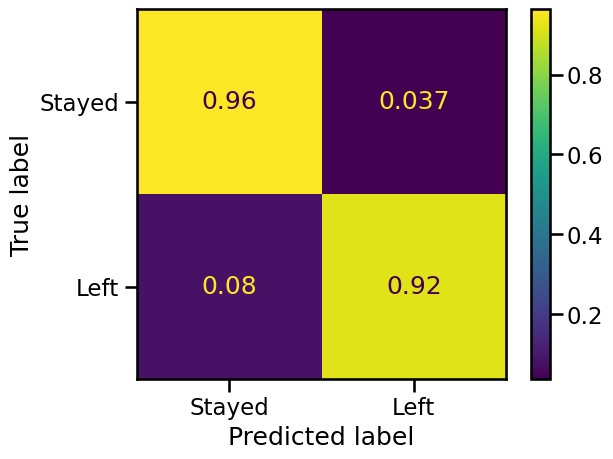

In [738]:
cf = confusion_matrix(y_test, knn_preds, normalize="true")

sns.set_context("talk")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf, display_labels=["Stayed", "Left"]
)
disp.plot()
plt.show()


The KNN model performs well, with strong recall and accuracy. It identifies many employees who left well. 
KNN is distance-based, meaning it considers distance to make predictions. It does not assume linear relationships.
This works well because employee with similar behavior pattern often forms local clusters. In this case, employees who are similar to each other tend to stay with the company for a long time.

- **Stayed** employees tend to stay with the company for a long time, and they are more likely to be in the same cluster.
- **Left** employees tend to leave the company quickly, and they are more likely to be in different clusters.


### **SVM Model**

SVM is a margin-based classifier. The RBF kernel allows nonlinear decision boundaries, and `class_weight='balanced'` helps account for the smaller `left = 1` class.


In [739]:
svm_model = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=True,
            ),
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                random_state=0,
            ),
        ),
    ]
)

svm_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [740]:
svm_preds = svm_model.predict(X_test)
print(classification_report(y_test, svm_preds, target_names=["Stayed", "Left"]))

              precision    recall  f1-score   support

      Stayed       0.99      0.97      0.98      2001
        Left       0.87      0.93      0.90       398

    accuracy                           0.96      2399
   macro avg       0.93      0.95      0.94      2399
weighted avg       0.97      0.96      0.97      2399



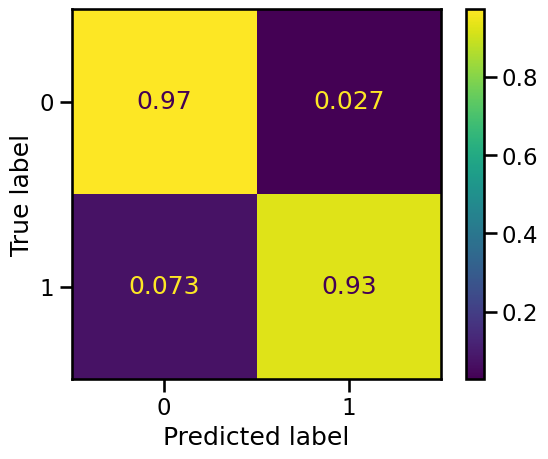

In [741]:
cf = confusion_matrix(y_test, svm_preds, normalize="true")

sns.set_context("talk")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf, display_labels=svm_model.classes_
)
disp.plot()
plt.show()


The SVM model achieved high recall and AUC scores, indicating that it performed well in identifying employees who were likely to leave the company. The model also performed better than logistic regression, suggesting that the relationship between features and employee turnover is likely nonlinear.

However, the model showed relatively low precision, meaning that some employees predicted to leave actually stayed.

The use of the RBF kernel allowed the SVM model to create nonlinear decision boundaries, helping it capture more complex patterns in the data.


### **Tree-based Model**
This approach covers implementation of Decision Tree and Random Forest. 

#### **Decision tree - Round 1**

Construct a decision tree model and set up cross-validated grid-search to exhuastively search for the best model parameters.

In [742]:
# Instantiate pipeline
tree_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=False,
            ),
        ),
        ("model", DecisionTreeClassifier(random_state=0)),
    ]
)

# Assign a dictionary of hyperparameters to search over
cv_params = {
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [2, 5, 1],
    "model__min_samples_split": [2, 4, 6],
}

# Assign a dictionary of scoring metrics to capture
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Instantiate GridSearch
tree1 = GridSearchCV(
    tree_pipeline, cv_params, scoring=scoring, cv=cv, refit="roc_auc"
)

Fit the decision tree model to the training data.

In [743]:
%%time
tree1.fit(X_train, y_train)

CPU times: user 3.22 s, sys: 0 ns, total: 3.22 s
Wall time: 3.21 s


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [2, 5, ...], 'model__min_samples_split': [2, 4, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


Identify the optimal values for the decision tree parameters.

In [744]:
# Check best parameters
tree1.best_params_

{'model__max_depth': 4,
 'model__min_samples_leaf': 5,
 'model__min_samples_split': 2}

The best first decision tree uses a maximum depth of 4, a minimum leaf size of 5, and a minimum split size of 2.


In [745]:
# Check best AUC score on CV
tree1.best_score_

0.972939302132388

The first decision tree has a cross-validated AUC of about 0.970. 
This is a strong AUC score, which shows that this model can predict employees who will leave very well.



In [746]:
tree1_preds = tree1.best_estimator_.predict(X_test)
print(
    "Decision Tree Round 1:\n",
    classification_report(y_test, tree1_preds, target_names=["Stayed", "Left"]),
)

Decision Tree Round 1:
               precision    recall  f1-score   support

      Stayed       0.98      0.99      0.98      2001
        Left       0.92      0.92      0.92       398

    accuracy                           0.97      2399
   macro avg       0.95      0.95      0.95      2399
weighted avg       0.97      0.97      0.97      2399



**Findings**

The decision tree model achieved high precision, recall, F1-score, and accuracy, indicating strong performance in predicting employee attrition.
The model performed well in identifying both employees who stayed and employees who left the company.

However, decision trees can overfit the training data. A random forest model may improve generalization and reduce overfitting by combining multiple decision trees.

#### **Random forest - Round 1**

Construct a random forest model and set up cross-validated grid-search to exhuastively search for the best model parameters.

In [747]:
# Instantiate pipeline
rf_pipeline = Pipeline(
    [
        (
            "preprocessor",
            make_preprocessor(
                numeric_features,
                binary_features,
                categorical_features,
                use_scaler=False,
            ),
        ),
        ("model", RandomForestClassifier(random_state=0)),
    ]
)

# Assign a dictionary of hyperparameters to search over
cv_params = {
    "model__max_depth": [5, None],
    "model__max_features": [1.0],
    "model__max_samples": [0.8],
    "model__min_samples_leaf": [1, 2],
    "model__min_samples_split": [2, 4],
    "model__n_estimators": [150],
}

# Assign a dictionary of scoring metrics to capture
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Instantiate GridSearch
rf1 = GridSearchCV(
    rf_pipeline, cv_params, scoring=scoring, cv=4, refit="roc_auc"
)

Fit the random forest model to the training data.

In [748]:
%%time
rf1.fit(X_train, y_train) # --> Wall time: ~10min

CPU times: user 23.2 s, sys: 0 ns, total: 23.2 s
Wall time: 23.2 s


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'model__max_depth': [5, None], 'model__max_features': [1.0], 'model__max_samples': [0.8], 'model__min_samples_leaf': [1, 2], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


The first random forest grid search completed successfully. It tested multiple forest settings to improve performance.


Specify path to where you want to save your model.

In [749]:
# Define a path to the folder where you want to save the model
path = Path.cwd()

Define functions to pickle the model and read in the model.

In [750]:
def write_pickle(path, model_object, save_as: str):
    """Save a model object as a pickle file."""
    save_path = Path(path) / f"{save_as}.pickle"
    with open(save_path, "wb") as to_write:
        pickle.dump(model_object, to_write)

In [751]:
def read_pickle(path, saved_model_name: str):
    """Read a pickled model object."""
    read_path = Path(path) / f"{saved_model_name}.pickle"
    with open(read_path, "rb") as to_read:
        model = pickle.load(to_read)

    return model

Use the functions defined above to save the model in a pickle file and then read it in.

In [752]:
# Write pickle
write_pickle(path, rf1, "hr_rf1")

In [753]:
# Read pickle
rf1 = read_pickle(path, "hr_rf1")

Identify the best AUC score achieved by the random forest model on the training set.

In [754]:
# Check best AUC score on CV
rf1.best_score_

0.9809058056947674

The first random forest has a cross-validated AUC of about 0.979. This is slightly better than the first decision tree.


Identify the optimal values for the parameters of the random forest model.

In [755]:
# Check best params
rf1.best_params_

{'model__max_depth': 5,
 'model__max_features': 1.0,
 'model__max_samples': 0.8,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 150}

The best first random forest uses 150 trees and a maximum depth of 5. These settings balance performance and model complexity.


Collect the evaluation scores on the training set for the decision tree and random forest models.

In [756]:
rf1_preds = rf1.best_estimator_.predict(X_test)
print(
    "Random Forest Round 1:\n",
    classification_report(y_test, rf1_preds, target_names=["Stayed", "Left"]),
)

Random Forest Round 1:
               precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2001
        Left       0.95      0.93      0.94       398

    accuracy                           0.98      2399
   macro avg       0.97      0.96      0.96      2399
weighted avg       0.98      0.98      0.98      2399




The random forest model achieved very strong performance, with 98% accuracy and high precision, recall, and F1-scores for both employees who stayed and employees who left.
The model performed especially well in predicting employee attrition, with a precision of 0.95 and recall of 0.93 for the “Left” class.

Overall, the results suggest that the random forest model is highly effective at identifying employee turnover patterns and generalizes well to unseen data.

#### **Feature Engineering**

The tree models achieved very high evaluation scores, but some of the features may contain data leakage. Data leakage happens when the model learns from information that would not realistically be available when making future predictions. This can lead to overly optimistic results that may not perform well in real-world use.

In this project, the `satisfaction_level` feature may cause leakage because employee satisfaction data may not always be available in practice. In addition, `average_monthly_hours` may indirectly reflect whether an employee has already decided to leave or has been identified for termination.

To reduce the risk of leakage, the final modeling round used feature engineering. The `satisfaction_level` column was removed, and a new binary feature called overworked was created based on monthly working hours. This feature was designed to capture whether an employee may be working excessive hours.

All final decision tree and random forest models were trained using this engineered dataset with the overworked feature instead of `satisfaction_level`.


In [757]:
# Drop `satisfaction_level` and save resulting dataframe in new variable
df2 = df1.drop("satisfaction_level", axis=1).copy()

# Display first few rows of new dataframe
df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.53,2,157,3,0,1,0,sales,low
1,0.86,5,262,6,0,1,0,sales,medium
2,0.88,7,272,4,0,1,0,sales,medium
3,0.87,5,223,5,0,1,0,sales,low
4,0.52,2,159,3,0,1,0,sales,low


The new dataframe removes `satisfaction_level`. This helps reduce possible data leakage from a feature that may be too directly related to leaving.


In [758]:
# Create `overworked` column. For now, it's identical to average monthly hours.
df2["overworked"] = df2["average_monthly_hours"]

# Inspect max and min average monthly hours values
print("Max hours:", df2["overworked"].max())
print("Min hours:", df2["overworked"].min())

Max hours: 310
Min hours: 96


Monthly hours range from 96 to 310. This range supports creating an `overworked` feature. An employee working 8 hours per day, 5 days per week, for 50 weeks per year would average about 166.67 monthly hours. Based on this, employees working more than 175 hours per month can be considered overworked.

The overworked feature can be converted into a binary variable using a boolean condition:

- `df2['overworked'] > 175` returns True for employees working more than 175 hours and False otherwise.
- `.astype(int)` converts True to 1 and False to 0.

In [759]:
# Define `overworked` as working more than 175 hours per month
df2["overworked"] = (df2["overworked"] > 175).astype(int)

# Display first few rows of new column
df2["overworked"].head()

0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

The `overworked` feature is now binary. A value of 1 means the employee worked more than 175 hours per month.


Drop the `average_monthly_hours` column.



In [760]:
# Drop the `average_monthly_hours` column
df2 = df2.drop("average_monthly_hours", axis=1)

# Display first few rows of resulting dataframe
df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,department,salary,overworked
0,0.53,2,3,0,1,0,sales,low,0
1,0.86,5,6,0,1,0,sales,medium,1
2,0.88,7,4,0,1,0,sales,medium,1
3,0.87,5,5,0,1,0,sales,low,1
4,0.52,2,3,0,1,0,sales,low,0


The detailed monthly hours column was removed after creating `overworked`. This keeps the model simpler and more interpretable.


Again, isolate the features and target variables

In [761]:
# Isolate the outcome variable
y_new = df2["left"].astype(int)

# Select the raw features
X_new = df2.drop("left", axis=1)

numeric_features_fe = ["last_evaluation", "number_project", "tenure"]
binary_features_fe = ["work_accident", "promotion_last_5years", "overworked"]
categorical_features_fe = ["department", "salary"]

preprocessor_fe = make_preprocessor(
    numeric_features_fe,
    binary_features_fe,
    categorical_features_fe,
    use_scaler=False,
)

X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,0,sales,low
1,0.80,0.86,5,262,6,0,0,sales,medium
2,0.11,0.88,7,272,4,0,0,sales,medium
3,0.72,0.87,5,223,5,0,0,sales,low
4,0.37,0.52,2,159,3,0,0,sales,low


Split the data into training and testing sets.

In [762]:
# Create test data
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.25, stratify=y_new, random_state=0
)

#### **Decision tree - Round 2**

In [763]:
# Instantiate pipeline
tree_pipeline_fe = Pipeline(
    [
        ("preprocessor", preprocessor_fe),
        ("model", DecisionTreeClassifier(random_state=0)),
    ]
)

# Assign a dictionary of hyperparameters to search over
cv_params = {
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [2, 5, 1],
    "model__min_samples_split": [2, 4, 6],
}

# Assign a dictionary of scoring metrics to capture
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Instantiate GridSearch
tree2 = GridSearchCV(
    tree_pipeline_fe, cv_params, scoring=scoring, cv=4, refit="roc_auc"
)

In [764]:
%%time
tree2.fit(X_train_new, y_train_new)

CPU times: user 2.06 s, sys: 0 ns, total: 2.06 s
Wall time: 2.06 s


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [2, 5, ...], 'model__min_samples_split': [2, 4, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"



The second decision tree grid search completed successfully using the revised feature set.


In [765]:
# Check best params
tree2.best_params_

{'model__max_depth': 6,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 6}


The best second decision tree uses a maximum depth of 6, a minimum leaf size of 2, and a minimum split size of 6.


In [766]:
# Check best AUC score on CV
tree2.best_score_

0.9571905320353831


The second decision tree has a cross-validated AUC of about 0.959. This is still strong after removing satisfaction level and detailed hours.


This model performs very well, even without satisfaction levels and detailed hours worked data. 

Next, check the other scores.

In [767]:
tree2_preds = tree2.best_estimator_.predict(X_test_new)
print(
    "Random Forest Round 2:\n",
    classification_report(
        y_test_new, tree2_preds, target_names=["Stayed", "Left"]
    ),
)

Random Forest Round 2:
               precision    recall  f1-score   support

      Stayed       0.98      0.95      0.97      2500
        Left       0.78      0.92      0.85       498

    accuracy                           0.94      2998
   macro avg       0.88      0.93      0.91      2998
weighted avg       0.95      0.94      0.95      2998



The second decision tree scores are lower than the first tree, but the model still performs well with fewer and cleaner features.


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

#### **Random forest - Round 2**

In [768]:
# Instantiate pipeline
rf_pipeline_fe = Pipeline(
    [
        ("preprocessor", preprocessor_fe),
        ("model", RandomForestClassifier(random_state=0)),
    ]
)

# Assign a dictionary of hyperparameters to search over
cv_params = {
    "model__max_depth": [5, None],
    "model__max_features": [1.0],
    "model__max_samples": [0.8],
    "model__min_samples_leaf": [1, 2],
    "model__min_samples_split": [2, 4],
    "model__n_estimators": [150],
}

# Assign a dictionary of scoring metrics to capture
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Instantiate GridSearch
rf2 = GridSearchCV(
    rf_pipeline_fe, cv_params, scoring=scoring, cv=4, refit="roc_auc"
)

In [769]:
%%time
rf2.fit(X_train_new, y_train_new) # --> Wall time: 7min 5s

CPU times: user 14.6 s, sys: 0 ns, total: 14.6 s
Wall time: 14.5 s


,estimator,Pipeline(step...om_state=0))])
,param_grid,"{'model__max_depth': [5, None], 'model__max_features': [1.0], 'model__max_samples': [0.8], 'model__min_samples_leaf': [1, 2], ...}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,None
,refit,'roc_auc'
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


The second random forest grid search completed successfully using the revised feature set.


In [770]:
# Write pickle
write_pickle(path, rf2, "hr_rf2")

In [771]:
# Read in pickle
rf2 = read_pickle(path, "hr_rf2")

In [772]:
# Check best params
rf2.best_params_

{'model__max_depth': 5,
 'model__max_features': 1.0,
 'model__max_samples': 0.8,
 'model__min_samples_leaf': 1,
 'model__min_samples_split': 4,
 'model__n_estimators': 150}

The best second random forest uses 150 trees, a maximum depth of 5, and balanced sampling settings.


In [773]:
# Check best AUC score on CV
rf2.best_score_

0.965272214018437

The second random forest has a cross-validated AUC of about 0.965. This is strong and better than the second decision tree by AUC.


In [774]:
rf2_preds = rf2.best_estimator_.predict(X_test_new)
print(
    "Random Forest Round 2:\n",
    classification_report(
        y_test_new, rf2_preds, target_names=["Stayed", "Left"]
    ),
)

Random Forest Round 2:
               precision    recall  f1-score   support

      Stayed       0.98      0.97      0.98      2500
        Left       0.87      0.91      0.89       498

    accuracy                           0.96      2998
   macro avg       0.93      0.94      0.93      2998
weighted avg       0.96      0.96      0.96      2998



The second random forest model achieved a cross-validated AUC of about 0.965, which is slightly better than the second decision tree model.

On the test set, the model achieved 96% accuracy with strong precision, recall, and F1-scores. The recall of 0.91 for the “Left” class indicates that the model was effective at identifying employees likely to leave.

Overall, the random forest model showed stable and balanced performance, making it a strong final model candidate.

Plot a confusion matrix to visualize how well it predicts on the test set.

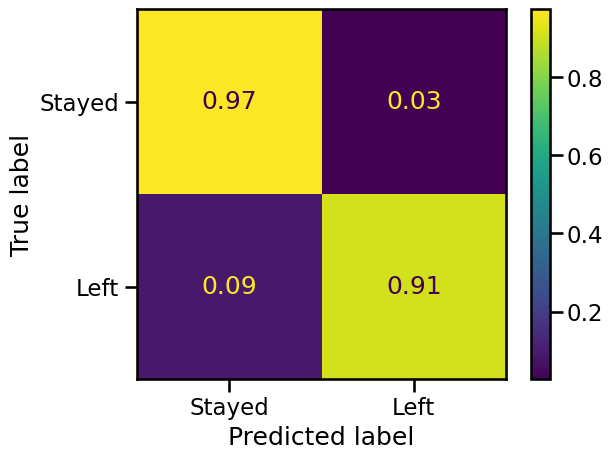

In [775]:
# Generate array of values for confusion matrix
preds = rf2.best_estimator_.predict(X_test_new)
cm = confusion_matrix(y_test_new, preds, labels=rf2.classes_, normalize="true")

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Stayed", "Left"]
)
disp.plot(values_format=".2f")

The confusion matrix shows that the model correctly predicted most employees who stayed and most employees who left.
The model produced slightly more false positives (68) than false negatives (45). This means the model is somewhat more likely to identify an employee as at risk of leaving when they actually stay, rather than miss an employee who truly leaves.
Overall, the low number of classification errors indicates that the random forest model performs strongly and is effective at predicting employee attrition.

#### **Decision tree splits**
For exploratory purpose, we we can also inspect the splits of the decision tree model and the most important features in the random forest model. 

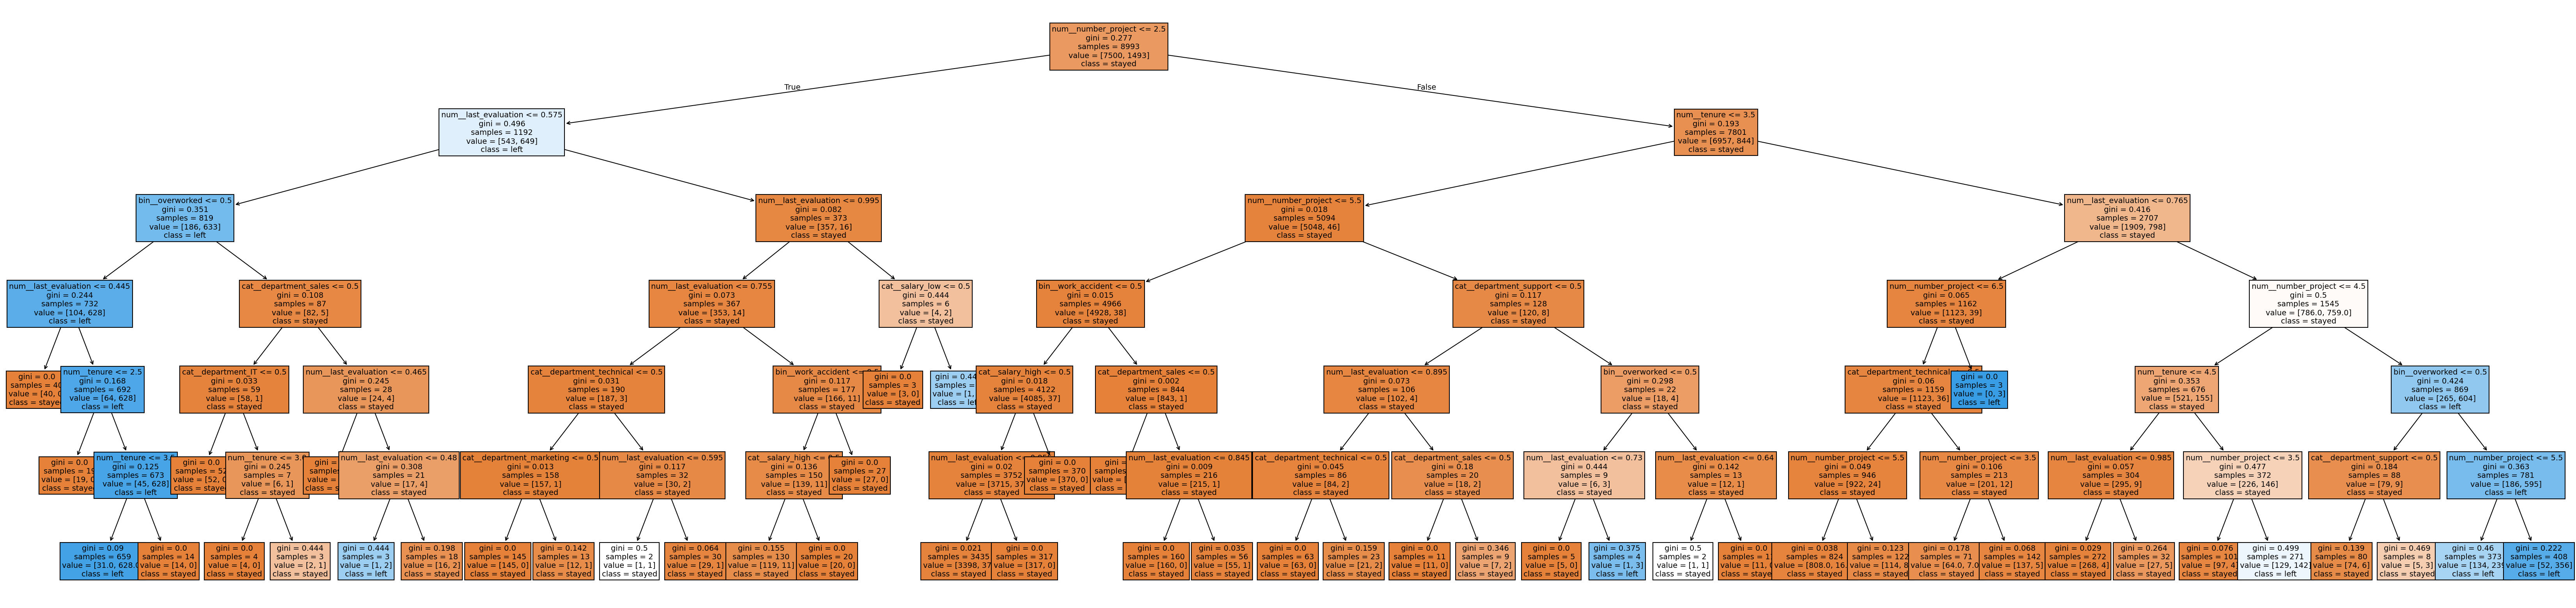

In [776]:
# Plot the decision tree inside the fitted pipeline
tree2_preprocessor = tree2.best_estimator_.named_steps["preprocessor"]
tree2_model = tree2.best_estimator_.named_steps["model"]
tree2_feature_names = tree2_preprocessor.get_feature_names_out()

plt.figure(figsize=(85, 20))
plot_tree(
    tree2_model,
    max_depth=6,
    fontsize=14,
    feature_names=tree2_feature_names,
    class_names=["stayed", "left"],
    filled=True,
)
plt.show()

The decision tree plot shows the main split rules. The most important splits use evaluation, project count, tenure, and overwork information.


#### **Decision tree feature importance**

WE can also get feature importance from decision trees (see the [DecisionTreeClassifier scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_) for details).

In [777]:
tree2_preprocessor = tree2.best_estimator_.named_steps["preprocessor"]
tree2_model = tree2.best_estimator_.named_steps["model"]
tree2_feature_names = tree2_preprocessor.get_feature_names_out()

tree2_importances = pd.DataFrame(
    tree2_model.feature_importances_,
    columns=["gini_importance"],
    index=tree2_feature_names,
)
tree2_importances = tree2_importances.sort_values(
    by="gini_importance", ascending=False
)

# Only extract the features with importances > 0
tree2_importances = tree2_importances[tree2_importances["gini_importance"] != 0]
tree2_importances

,gini_importance
num__last_evaluation,0.343958
num__number_project,0.343385
num__tenure,0.215681
bin__overworked,0.093498
cat__department_support,0.001142
cat__salary_low,0.000737
cat__department_sales,0.000607
cat__department_technical,0.000418
bin__work_accident,0.000183
cat__salary_high,0.000173


We create a barplot to visualize the decision tree feature importances.

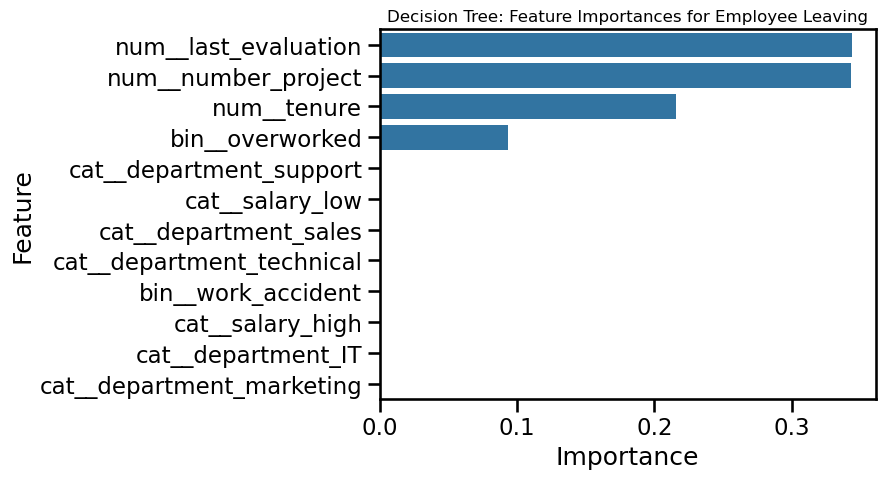

In [778]:
sns.barplot(
    data=tree2_importances,
    x="gini_importance",
    y=tree2_importances.index,
    orient="h",
)
plt.title(
    "Decision Tree: Feature Importances for Employee Leaving", fontsize=12
)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

The feature importance plot shows that `last_evaluation`, `number_project`, `tenure`, and `overworked` are the most important predictors of employee attrition.
Among these features, `last_evaluation` and `number_project` have the strongest influence on the decision tree model’s predictions.

This suggests that employee workload, performance evaluation, and years at the company are key factors associated with employees leaving the company.

#### **Random forest feature importance**

Now, plot the feature importances for the random forest model.

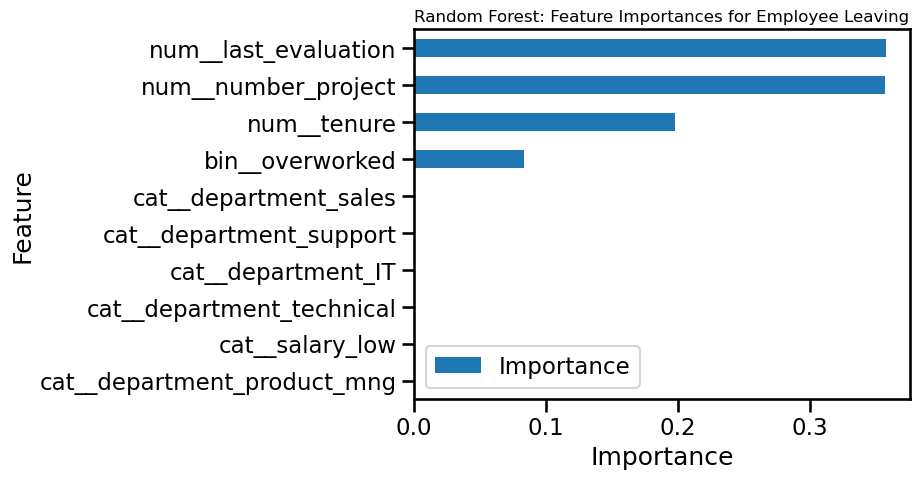

In [779]:
# Get feature importances from the random forest inside the fitted pipeline
rf2_preprocessor = rf2.best_estimator_.named_steps["preprocessor"]
rf2_model = rf2.best_estimator_.named_steps["model"]
rf2_feature_names = rf2_preprocessor.get_feature_names_out()
feat_impt = rf2_model.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(feat_impt, -10)[-10:]

# Get column labels and importances of top 10 features
feat = rf2_feature_names[ind]
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature": feat, "Importance": feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind="barh", ax=ax1, x="Feature", y="Importance")

ax1.set_title(
    "Random Forest: Feature Importances for Employee Leaving", fontsize=12
)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()


The random forest feature importance plot shows that `last_evaluation`, `number_project`, `tenure`, and `overworked` are the strongest predictors of employee attrition.

Among these variables, `last_evaluation` and `number_project` have the highest importance scores, indicating that employee performance and workload are major factors associated with employees leaving the company.

The random forest and decision tree models identified similar important features, suggesting that these predictors are consistently influential across different models.


### **XGBoost Model**

XGBoost is a boosted tree model. It can capture nonlinear patterns and interactions while using regularization to control overfitting. `scale_pos_weight` helps address class imbalance.


In [780]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = Pipeline(
    [
        ("preprocessor", preprocessor_fe),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=0,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_model.fit(X_train_new, y_train_new)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [781]:
xgb_preds = xgb_model.predict(X_test_new)
print(
    "XGBoost Round 1:\n",
    classification_report(
        y_test_new, xgb_preds, target_names=["Stayed", "Left"]
    ),
)

XGBoost Round 1:
               precision    recall  f1-score   support

      Stayed       0.99      0.94      0.96      2500
        Left       0.76      0.93      0.84       498

    accuracy                           0.94      2998
   macro avg       0.87      0.94      0.90      2998
weighted avg       0.95      0.94      0.94      2998





The XGBoost model achieved high recall (0.93) for the “Left” class, showing strong ability to identify employees likely to leave.

The model also achieved 94% overall accuracy. However, its precision for the “Left” class (0.76) was lower than the random forest model, indicating more false positive predictions.

Overall, XGBoost performed well and was effective at detecting employee attrition

### **Stacking Ensemble**

Stacking combines multiple model types. Here, logistic regression, random forest, and XGBoost are used as base models, and logistic regression is used as the final meta-model.


In [782]:
stacking_model = Pipeline(
    [
        ("preprocessor", preprocessor_fe),
        (
            "model",
            StackingClassifier(
                estimators=[
                    (
                        "lr",
                        Pipeline(
                            [
                                ("scaler", StandardScaler()),
                                (
                                    "lr",
                                    LogisticRegression(
                                        max_iter=1000,
                                        class_weight="balanced",
                                        random_state=0,
                                    ),
                                ),
                            ]
                        ),
                    ),
                    (
                        "rf",
                        RandomForestClassifier(
                            n_estimators=150,
                            max_depth=None,
                            min_samples_leaf=2,
                            class_weight="balanced",
                            random_state=0,
                            n_jobs=-1,
                        ),
                    ),
                    (
                        "xgb",
                        XGBClassifier(
                            objective="binary:logistic",
                            eval_metric="logloss",
                            n_estimators=150,
                            max_depth=3,
                            learning_rate=0.05,
                            subsample=0.8,
                            colsample_bytree=0.8,
                            scale_pos_weight=scale_pos_weight,
                            random_state=0,
                            n_jobs=-1,
                        ),
                    ),
                ],
                final_estimator=LogisticRegression(
                    max_iter=1000, class_weight="balanced", random_state=0
                ),
                cv=5,
                n_jobs=-1,
            ),
        ),
    ]
)

stacking_model.fit(X_train_new, y_train_new)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [783]:
stacking_preds = stacking_model.predict(X_test_new)
print(
    "Stacking:\n",
    classification_report(
        y_test_new, stacking_preds, target_names=["Stayed", "Left"]
    ),
)

Stacking:
               precision    recall  f1-score   support

      Stayed       0.98      0.95      0.97      2500
        Left       0.78      0.92      0.84       498

    accuracy                           0.94      2998
   macro avg       0.88      0.93      0.90      2998
weighted avg       0.95      0.94      0.94      2998




The stacking model achieved 94% accuracy with strong recall (0.92) for the “Left” class, showing good performance in identifying employees likely to leave.

Compared with XGBoost, the stacking model slightly improved precision for the “Left” class, reducing false positive predictions.

Overall, the stacking model performed well, but its performance was similar to the final random forest model rather than clearly better.

### **Combined Model Comparison**

This table combines the current champion random forest with the added Course 3 models and imbalance-handling approaches.


In [784]:
# Global list to store results
all_results = []


def evaluate_and_store(model_name, y_true, y_pred):

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1_Score": f1_score(y_true, y_pred),
    }

    all_results.append(result)

    return result


log_clf_score = evaluate_and_store(
    "Logistic Regression", y_test, log_clf.predict(X_test)
)

log_clf_l1_score = evaluate_and_store(
    "Logistic Regression L1", y_test, log_clf_l1.predict(X_test)
)

log_clf_l2_score = evaluate_and_store(
    "Logistic Regression L2", y_test, log_clf_l2.predict(X_test)
)

knn_score = evaluate_and_store("KNN", y_test, knn_model.predict(X_test))

svm_score = evaluate_and_store("SVM", y_test, svm_model.predict(X_test))

tree1_score = evaluate_and_store(
    "Decision Tree Round 1", y_test, tree1.best_estimator_.predict(X_test)
)

rf1_score = evaluate_and_store(
    "Random Forest Round 1", y_test, rf1.best_estimator_.predict(X_test)
)

tree2_score = evaluate_and_store(
    "Decision Tree Round 2",
    y_test_new,
    tree2.best_estimator_.predict(X_test_new),
)

rf2_score = evaluate_and_store(
    "Random Forest Round 2", y_test_new, rf2.best_estimator_.predict(X_test_new)
)

xgb_score = evaluate_and_store(
    "XGBoost", y_test_new, xgb_model.predict(X_test_new)
)

stacking_model_score = evaluate_and_store(
    "Stacking Model", y_test_new, stacking_model.predict(X_test_new)
)

# Create DataFrame from the global list
results_df = pd.DataFrame(all_results)

In [785]:
# Display the summary table
print("Summary of All Model Performances:")
display(results_df)

Summary of All Model Performances:


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.788245,0.429668,0.844221,0.569492
1,Logistic Regression L1,0.784077,0.424433,0.846734,0.565436
2,Logistic Regression L2,0.785327,0.425667,0.841709,0.565401
3,KNN,0.955815,0.831818,0.919598,0.873508
4,SVM,0.964985,0.870283,0.927136,0.897810
5,Decision Tree Round 1,0.974156,0.924242,0.919598,0.921914
6,Random Forest Round 1,0.979575,0.948586,0.927136,0.937738
7,Decision Tree Round 2,0.944296,0.783877,0.917671,0.845513
8,Random Forest Round 2,0.962308,0.869482,0.909639,0.889107
9,XGBoost,0.940294,0.762768,0.929719,0.838009



The comparison table shows clear performance differences across the models. Logistic regression models had the lowest performance, while KNN, SVM, decision tree, random forest, XGBoost, and stacking models achieved much higher accuracy, recall, and F1-scores.

The first decision tree and random forest models achieved the strongest overall performance, but they used features that included satisfaction_level and average_monthly_hours, which may introduce data leakage.

Models 7–10 were trained using the engineered dataset where `satisfaction_level` and `average_monthly_hours` were removed and replaced with the overworked feature. Although these models showed slightly lower performance, they are more realistic and reliable for real-world prediction.

Among the engineered-feature models, the second random forest model provided the best balance between accuracy, precision, recall, and interpretability, making it the strongest final model candidate.


### **Model Explanation**
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders



#### **Permutationion Importance**

To make the final model more useful to HR stakeholders, this section explains the selected random forest model using permutation importance and partial dependence plots. Permutation importance shows which features affect performance most. PDPs show how the model's average prediction changes as important features change.


In [786]:
# Permutation importance for the selected random forest model
perm_importance = permutation_importance(
    rf2.best_estimator_,
    X_test_new,
    y_test_new,
    n_repeats=5,
    scoring="f1",
    random_state=0,
    n_jobs=-1,
)

perm_importance_df = pd.DataFrame(
    {
        "feature": X_test_new.columns,
        "importance_mean": perm_importance.importances_mean,
        "importance_std": perm_importance.importances_std,
    }
).sort_values("importance_mean", ascending=False)

perm_importance_df.head(10)

,feature,importance_mean,importance_std
1,number_project,0.542862,0.018622
0,last_evaluation,0.420419,0.029951
2,tenure,0.313804,0.020818
7,overworked,0.297121,0.010177
3,work_accident,0.000000,0.000000
4,promotion_last_5years,0.000000,0.000000
5,department,0.000000,0.000000
6,salary,0.000000,0.000000


Permutation importance shows that `number_project` and `last_evaluation` have the largest effect on model performance. These are the strongest drivers in the final model.


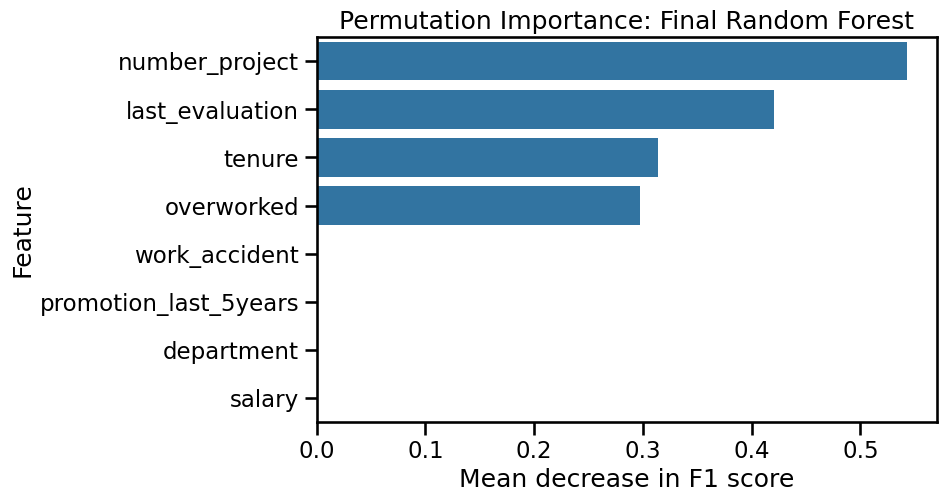

In [787]:
# Visualize top permutation importances
plt.figure(figsize=(8, 5))
sns.barplot(
    data=perm_importance_df.head(10),
    x="importance_mean",
    y="feature",
    orient="h",
)
plt.title("Permutation Importance: Final Random Forest")
plt.xlabel("Mean decrease in F1 score")
plt.ylabel("Feature")
plt.show()


The permutation importance analysis shows that `number_project`, `last_evaluation`, `tenure`, and `overworked` are the most important features in the final random forest model. Among these features, `number_project` has the largest impact on model performance, followed by `last_evaluation`.

The results suggest that employee workload, performance evaluation, and years at the company are the main factors associated with employee attrition.

#### **Partial Dependence Plots** 

/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/wusu/anaconda3/envs/Python_3_10/lib/py

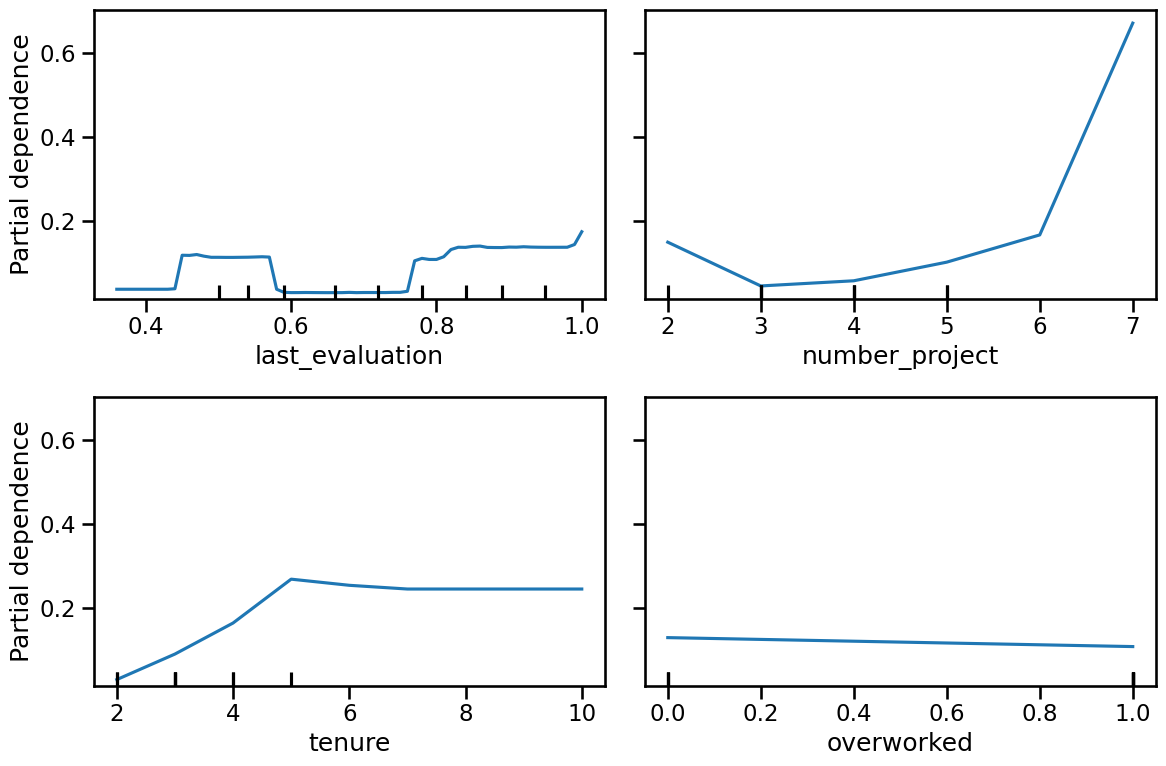

In [788]:
# Partial dependence plots for important interpretable features
pdp_features = ["last_evaluation", "number_project", "tenure", "overworked"]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    rf2.best_estimator_,
    X_train_new,
    features=pdp_features,
    random_state=rs,
    ax=ax,
)

plt.tight_layout()
plt.show()


The partial dependence plots show how individual features affect the predicted risk of employee attrition in the final random forest model.

Employee attrition risk increases sharply as the number of projects rises, especially at very high project counts. Attrition risk also increases with longer tenure up to around five years before stabilizing.

`last_evaluation` shows a nonlinear relationship with attrition risk, while the overworked feature has a smaller but still noticeable effect on the model’s predictions.

Overall, the plots suggest that workload, performance evaluation, and years at the company are key factors influencing employee turnover.

#### **Local Explanation with LIME**

LIME explains one prediction at a time. This is useful when HR leaders want to understand why one employee was flagged as higher risk. If `lime` is not installed in the environment, this cell will skip the explanation.


Predicted probability of leaving: 0.011908780632166775


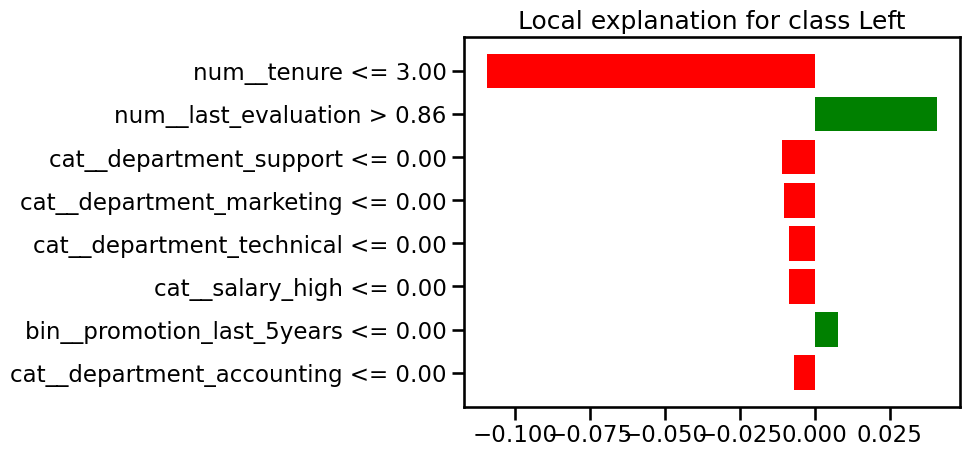

In [789]:
import lime.lime_tabular

# Get transformed training and test data
X_train_lime = rf2.best_estimator_.named_steps["preprocessor"].transform(
    X_train_new
)
X_test_lime = rf2.best_estimator_.named_steps["preprocessor"].transform(
    X_test_new
)


# Create explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_lime,
    feature_names=rf2.best_estimator_.named_steps[
        "preprocessor"
    ].get_feature_names_out(),
    class_names=["Stayed", "Left"],
    mode="classification",
    random_state=0,
)

# Explain one employee
i = 0

exp = explainer.explain_instance(
    X_test_lime[i],
    rf2.best_estimator_.named_steps["model"].predict_proba,
    num_features=8,
)

print(
    "Predicted probability of leaving:",
    rf2.best_estimator_.predict_proba(X_test_new.iloc[[i]])[0, 1],
)

exp.as_pyplot_figure()
plt.show()


The LIME explanation shows how individual features influenced the prediction for one employee.

For this employee, short tenure (`tenure` <= 3) was the strongest factor reducing the predicted risk of leaving. In contrast, a high performance evaluation (`last_evaluation` > 0.86) slightly increased the predicted attrition risk.

Other features, such as department and salary category, had smaller effects on the prediction.

Overall, the model predicted a relatively low probability that this employee would leave the company.

#### **Summary**

The three explanation methods showed consistent results. Permutation importance, partial dependence plots, and LIME all identified `number_project`, `last_evaluation`, `tenure`, and `overworked` as the main factors related to employee attrition.

Permutation importance showed which features were most important for the overall model. Partial dependence plots showed how changes in these features affected attrition risk across all employees. For example, attrition risk increased when employees had very high project counts or longer tenure.

LIME explained predictions for one specific employee and confirmed that the same important features also influenced individual predictions.

Together, these methods helped explain both the overall behavior of the model and the reasons behind individual predictions.

## **Model Comparison**

Several classification models were tested, including Logistic Regression, KNN, SVM, Decision Tree, Random Forest, XGBoost, and a Stacking model.

Logistic regression showed the weakest performance, suggesting that employee attrition patterns were not linearly separable. KNN and SVM achieved much higher recall and F1-scores because they captured more complex nonlinear relationships in the data.

The first decision tree and random forest models achieved the highest scores, but they used features that may contain data leakage. The final models used the engineered dataset after removing `satisfaction_level` and `average_monthly_hours`.

Among the final models, the random forest model achieved the best balance between accuracy, recall, precision, and interpretability, with about 96% accuracy and strong performance in identifying employees likely to leave. XGBoost and the stacking model also performed well, but their improvements over the final random forest model were relatively small while requiring greater model complexity. The final random forest model was selected because it achieved strong recall while maintaining balanced precision, interpretability, and stable performance across evaluation metrics.

Recall was especially important in this project because failing to identify employees likely to leave could prevent the company from taking early retention actions.


## **Final Model Selection**

| Model               | Accuracy | Recall (Left) | F1 Score | Notes                       |
| ------------------- | -------- | ------------- | -------- | --------------------------- |
| Logistic Regression | 0.79     | 0.84          | 0.57     | Simple, interpretable       |
| KNN                 | 0.96     | 0.92          | 0.87     | Strong performance          |
| SVM                 | 0.96     | 0.93          | 0.90     | Strong balanced performance |
| Random Forest       | 0.98     | 0.93          | 0.94     | Best balance                |
| XGBoost             | 0.94     | 0.93          | 0.84     | Strong but more complex     |
| Stacking            | 0.94     | 0.92          | 0.84     | High performance ensemble   |

The Random Forest model provided the best balance between predictive performance and interpretability. Although XGBoost and stacking also performed well, Random Forest produced clearer feature importance and more stable classification results.

## **Model Interpretation**

Permutation importance, partial dependence plots, and LIME produced consistent results. All three methods identified `number_project`, `last_evaluation`, `tenure`, and `overworked` as the main factors related to employee attrition.

Permutation importance showed which features had the largest overall impact on model performance. Partial dependence plots showed that attrition risk increased for employees with very high project counts and longer tenure. LIME explained predictions for individual employees and confirmed that the same important features also influenced local predictions.

Together, these methods helped explain both the overall behavior of the model and the reasons behind individual predictions.

## **Key Findings and Insights**

The analysis showed that employee attrition is strongly associated with workload, project count, tenure, and employee evaluation patterns.

Employees handling very high numbers of projects were much more likely to leave the company. Long working hours and low satisfaction scores were also strongly related to attrition risk.

Permutation importance, partial dependence plots, and LIME explanations consistently identified project count, tenure, evaluation score, and overwork as the most important predictive features.

Recommendations:
- Monitor employees with excessive workloads
- Improve workload balance across teams
- Investigate employees with unusually high evaluation scores but very long working hours
- Provide stronger retention support for mid-tenure employees

## **Limitations and Future Work**

This project has several limitations.

The dataset may not fully represent real-world employee behavior because some patterns appear unusually structured. The dataset also lacks important information such as manager relationships, employee engagement surveys, compensation history, and external economic factors.

Although the models achieved strong performance, class imbalance may still affect prediction quality for employees who leave.

Future work could include:
- collecting additional employee behavior data,
- testing advanced boosting models,
- improving feature engineering,
- applying resampling techniques,
- validating the models on external HR datasets.

## **Conclusion**

This project developed and compared multiple supervised classification models to predict employee attrition.

The Random Forest model achieved the best overall balance between performance and interpretability. The analysis showed that excessive workload, project count, tenure, and evaluation patterns are strongly associated with employee turnover.

These findings can help HR teams identify employees at risk of leaving and improve retention strategies through better workload management and employee support.

## **Author**
Su Wu